In [140]:
import matplotlib.pyplot as plt
import astricaltools as at
import numpy as np
import pandas as pd
import scipy.stats as sc
from astropy import stats
import astropy.units as u
from astropy.io import fits
from astropy.table import vstack, Table
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.coordinates import SkyCoord, EarthLocation, AltAz, Angle

In [141]:
file_numbers = range(1, 10)  # da 001 a 009
base_path = "astri_{:03d}_43_009_00002_R_200101_001_0201_SEB.lv0"  # pattern del nome file

dfs = []  # lista per accumulare i DataFrame
print("\n")
for i in file_numbers:
    filename = base_path.format(i)
    print(f"{filename}")

    with at.io.fits.AstriFits(filename) as hdul:
        data = hdul[1].data

        # Conversione dei campi
        time_ns = data["TIME_NS"].byteswap().newbyteorder().astype(np.int64)
        time_s  = data["TIME_S"].byteswap().newbyteorder().astype(np.int64)
        event   = data["EVTNUM"].byteswap().newbyteorder().astype(np.int64)
        mcrun   = data["MCRUNNUM"].byteswap().newbyteorder().astype(np.int64)
        ntel= data["NTRIGTEL"]
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
        hg, lg, ttp = hdul.get_data('events', ['hi', 'lo', 'ttp'])
        time_abs = time_s * 10**9 + time_ns  # tempo assoluto in ns
            #creo il dataframe
        df = pd.DataFrame({
                "TIME_NS": time_ns,
                "TIME_S": time_s,
                "TIME_ABS": time_abs,
                "EVENT": event,
                "MCRUN": mcrun,
                "TEL_ID": i,
                "num_tel": ntel,
                "HG": list(hg),             
                "LG": list(lg),
                "TTP": list(ttp),
            })

        dfs.append(df)
df_all = pd.concat(dfs, ignore_index=True)
df_all_sorted= df_all.sort_values(by="TIME_ABS").reset_index(drop=True)
#mask=df_all_sorted["HG"]>2400
df_all_sorted["shape"] = df_all_sorted["HG"].apply(np.sum).to_numpy()
#df
#print(df_all_sorted.head())
#print(len(df_all_sorted))




astri_001_43_009_00002_R_200101_001_0201_SEB.lv0
astri_002_43_009_00002_R_200101_001_0201_SEB.lv0
astri_003_43_009_00002_R_200101_001_0201_SEB.lv0
astri_004_43_009_00002_R_200101_001_0201_SEB.lv0
astri_005_43_009_00002_R_200101_001_0201_SEB.lv0
astri_006_43_009_00002_R_200101_001_0201_SEB.lv0
astri_007_43_009_00002_R_200101_001_0201_SEB.lv0
astri_008_43_009_00002_R_200101_001_0201_SEB.lv0
astri_009_43_009_00002_R_200101_001_0201_SEB.lv0


/tmp/ipykernel_652027/3980954610.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


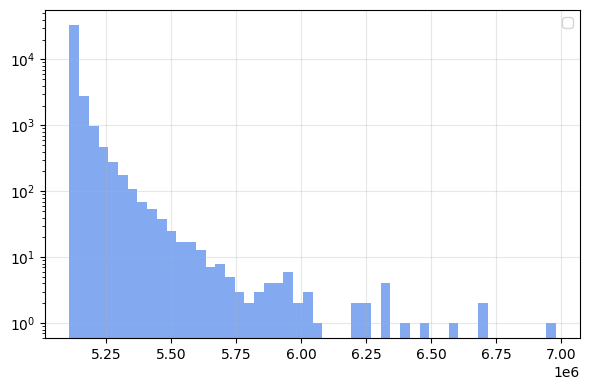

In [142]:
plt.figure(figsize=(6, 4))
plt.hist(df_all_sorted["shape"], bins=50, color='cornflowerblue',alpha=0.8)
plt.yscale("log")
plt.tight_layout()
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [143]:
for iv, row in df_all_sorted.iterrows():

        itel = row["TEL_ID"]
        event = row["EVENT"]     
        mcrun = row["MCRUN"]     
        
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        #pxmask=ttpev==255
        print(np.sum(pxmask),np.sum(hgev[pxmask]), row["shape"]/1e4 )

        if iv>20:
                break
        

1 2471 511.7779
4 10173 512.3973
74 232051 520.3412
27 77984 514.4356
2 4832 512.0308
522 1674929 571.5558
89 292243 522.7474
23 68546 514.5447
21 62341 514.6453
84 273484 522.1609
1 2432 512.1872
0 0 512.2435
1 2455 512.6452
3 7259 512.4624
0 0 511.4461
3 7241 511.8912
2 4843 511.7648
1 2401 512.192
0 0 512.7801
2 5020 511.5119
19 48071 513.0309
6 14832 512.5593


Eventi rimasti dopo il taglio: 13417


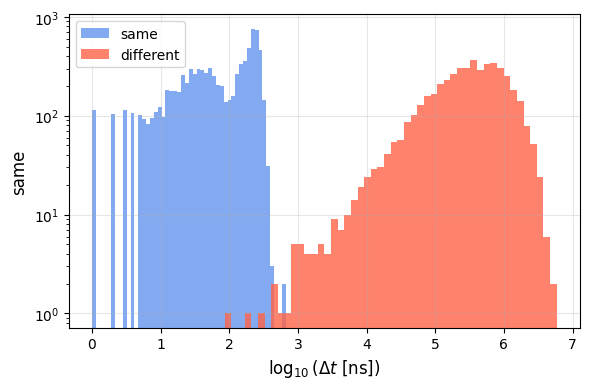

In [144]:
delta_t=np.diff(df_all_sorted["TIME_ABS"])
delta_ts = delta_t[delta_t > 0] #uso maschere e cambio
#================================ LAVORO SUI TAGLI =================================
df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.125e6]    ##                            taglio  su size
#df_all_sorted=df_all_sorted[df_all_sorted["num_tel"]>=3]
#taglio sui pixel
min_pixels = 5

# Funzione che conta i pixel validi per ogni riga
def count_valid_pixels(row):
    hgev = np.array(row["HG"])
    ttpev = np.array(row["TTP"])
    pxmask = (hgev > 2400) & (ttpev < 255)
    return np.sum(pxmask)

# Applica la funzione a tutto il dataframe
df_all_sorted["n_valid_pixels"] = df_all_sorted.apply(count_valid_pixels, axis=1)

# Filtra tenendo solo gli eventi con almeno min_pixels pixel validi
df_all_sorted = df_all_sorted[df_all_sorted["n_valid_pixels"] >= min_pixels].reset_index(drop=True)

print(f"Eventi rimasti dopo il taglio: {len(df_all_sorted)}")


#===================================================================================
#ordino eventi con il for e suddivisione same e different
df_all_sorted=df_all_sorted.sort_values(["MCRUN","EVENT","TIME_ABS"]).reset_index(drop=True)
#df_all_sorted = df_all.sort_values(by=["MCRUN", "EVENT", "TIME_ABS"]).reset_index(drop=True)
delta_t_same = []
delta_t_diff = []

for i in range(1, len(df_all_sorted)):
    if ((df_all_sorted.loc[i, "MCRUN"]==df_all_sorted.loc[i-1, "MCRUN"])&
        (df_all_sorted.loc[i, "EVENT"] ==df_all_sorted.loc[i-1, "EVENT"])):
        delta_t_same.append(df_all_sorted.loc[i, "TIME_ABS"]-
                            df_all_sorted.loc[i-1, "TIME_ABS"])
    else:
        delta_t_diff.append(df_all_sorted.loc[i, "TIME_ABS"]-
                            df_all_sorted.loc[i-1, "TIME_ABS"])
delta_t_same = np.array(delta_t_same)
delta_t_diff = np.array(delta_t_diff)
delta_t_same_safe = np.where(delta_t_same > 0, delta_t_same, 1)
delta_t_diff_safe = np.where(delta_t_diff > 0, delta_t_diff, 1)
#suddivido tra stesso evento e evento separato sostituendo i deltat con 1
plt.figure(figsize=(6, 4))
plt.hist(np.log10(delta_t_same[delta_t_same > 0]), bins=50, color='cornflowerblue',
         alpha=0.8,label='same')
plt.hist(np.log10(delta_t_diff[delta_t_diff > 0]),bins=50, color='tomato',
         alpha=0.8,label='different')
plt.yscale('log')
plt.xlabel(r'$\log_{10}(\Delta t\ \mathrm{[ns]})$', fontsize=12)
plt.ylabel('same', fontsize=12)
#plt.xlim(left=0)
plt.tight_layout()
plt.grid(alpha=0.3)
plt.legend()
plt.show()


In [145]:

threshold_ns = 1000  # equivalente a log10(delta_t) < 3

#delta_t entro la soglia
delta_t_same_window = delta_t_same[(delta_t_same > 0) & (delta_t_same < threshold_ns)]
delta_t_diff_window = delta_t_diff[(delta_t_diff > 0) & (delta_t_diff < threshold_ns)]

n_same_in_window = len(delta_t_same_window)
n_diff_in_window = len(delta_t_diff_window)
total_in_window = n_same_in_window + n_diff_in_window

print(f"Eventi nella finestra temporale (Δt < {threshold_ns} ns):")
print(f"  - Stesso evento (same): {n_same_in_window} ({n_same_in_window/total_in_window*100:.1f}%)")
print(f"  - Eventi diversi (different): {n_diff_in_window} ({n_diff_in_window/total_in_window*100:.1f}%)")
print(f"  - Totale: {total_in_window}")

# Se vuoi salvare gli indici degli eventi originali nella finestra temporale
indices_same_window = []
indices_diff_window = []

for i in range(1, len(df_all_sorted)):
    dt = df_all_sorted.loc[i, "TIME_ABS"] - df_all_sorted.loc[i-1, "TIME_ABS"]
    
    if 0 < dt < threshold_ns:
        if ((df_all_sorted.loc[i, "MCRUN"] == df_all_sorted.loc[i-1, "MCRUN"]) &
            (df_all_sorted.loc[i, "EVENT"] == df_all_sorted.loc[i-1, "EVENT"])):
            indices_same_window.append(i)
        else:
            indices_diff_window.append(i)

# Crea dataframe con solo gli eventi nella finestra
df_same_window = df_all_sorted.loc[indices_same_window].copy()
df_diff_window = df_all_sorted.loc[indices_diff_window].copy()

print(f"\nRighe del dataframe nella finestra:")
print(f"  - Same events: {len(df_same_window)}")
print(f"  - Different events: {len(df_diff_window)}")



Eventi nella finestra temporale (Δt < 1000 ns):
  - Stesso evento (same): 8703 (99.9%)
  - Eventi diversi (different): 12 (0.1%)
  - Totale: 8715

Righe del dataframe nella finestra:
  - Same events: 8703
  - Different events: 12


In [146]:
threshold_ns = 1000

# Conta i delta_t
delta_t_same_window = delta_t_same[(delta_t_same > 0) & (delta_t_same < threshold_ns)]
delta_t_diff_window = delta_t_diff[(delta_t_diff > 0) & (delta_t_diff < threshold_ns)]

n_same_transitions = len(delta_t_same_window)
n_diff_transitions = len(delta_t_diff_window)
total_transitions = n_same_transitions + n_diff_transitions

print(f"Transizioni temporali (Δt < {threshold_ns} ns):")
print(f"  - Stesso evento: {n_same_transitions} ({n_same_transitions/total_transitions*100:.1f}%)")
print(f"  - Eventi diversi: {n_diff_transitions} ({n_diff_transitions/total_transitions*100:.1f}%)")
print(f"  - Totale transizioni: {total_transitions}")

# Ora conta i TIME_GROUP
#creazione dei time_group
df_all_sorted = df_all_sorted.sort_values('TIME_ABS').reset_index(drop=True)

#Calcolare le differenze temporali tra eventi consecutivi
df_all_sorted['dt'] = df_all_sorted['TIME_ABS'].diff()

# Creare gruppi temporali basati sulla soglia
# Quando dt > threshold_ns, inizia un nuovo gruppo
df_all_sorted['new_group'] = (df_all_sorted['dt'] > threshold_ns) | (df_all_sorted['dt'].isna())
df_all_sorted['time_group'] = df_all_sorted['new_group'].cumsum()


group_info = df_all_sorted.groupby('time_group').agg({
    'EVENT': 'nunique',
    'MCRUN': 'nunique'
}).reset_index()

group_info['is_mixed'] = (group_info['EVENT'] > 1) | (group_info['MCRUN'] > 1)

n_pure_groups = (~group_info['is_mixed']).sum()
n_mixed_groups = group_info['is_mixed'].sum()
total_groups = len(group_info)

print(f"\nTime groups (finestre temporali):")
print(f"  - Pure (stesso evento): {n_pure_groups} ({n_pure_groups/total_groups*100:.1f}%)")
print(f"  - Miste (eventi diversi): {n_mixed_groups} ({n_mixed_groups/total_groups*100:.1f}%)")
print(f"  - Totale groups: {total_groups}")





Transizioni temporali (Δt < 1000 ns):
  - Stesso evento: 8703 (99.9%)
  - Eventi diversi: 12 (0.1%)
  - Totale transizioni: 8715

Time groups (finestre temporali):
  - Pure (stesso evento): 4629 (99.7%)
  - Miste (eventi diversi): 13 (0.3%)
  - Totale groups: 4642


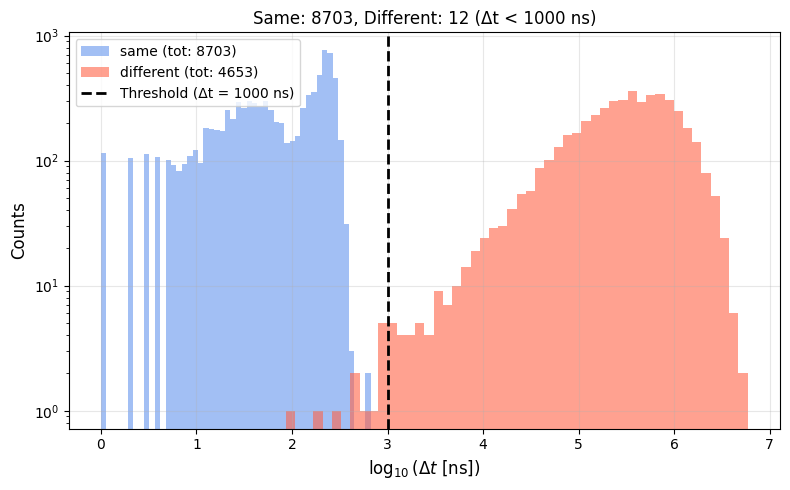

In [147]:

plt.figure(figsize=(8, 5))
plt.hist(np.log10(delta_t_same[delta_t_same > 0]), bins=50, color='cornflowerblue',
         alpha=0.6, label=f'same (tot: {len(delta_t_same[delta_t_same > 0])})')
plt.hist(np.log10(delta_t_diff[delta_t_diff > 0]), bins=50, color='tomato',
         alpha=0.6, label=f'different (tot: {len(delta_t_diff[delta_t_diff > 0])})')

# Linea verticale alla soglia
plt.axvline(x=3, color='black', linestyle='--', linewidth=2, 
            label=f'Threshold (Δt = {threshold_ns} ns)')

plt.yscale('log')
plt.xlabel(r'$\log_{10}(\Delta t\ \mathrm{[ns]})$', fontsize=12)
plt.ylabel('Counts', fontsize=12)
plt.title(f'Same: {n_same_in_window}, Different: {n_diff_in_window} (Δt < {threshold_ns} ns)')
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [148]:


#=========================== INSERISCO CONTROLLO TEMPI MORTI ===========================================
# Ordina per time_group TIME_ABS
df_all_sorted = df_all_sorted.sort_values(by=["time_group", "TIME_ABS"]).reset_index(drop=True)

# TIENE IL TELESCOPIO ARRIVATO PRIMA
df_all_sorted = df_all_sorted.drop_duplicates(subset=['time_group', 'TEL_ID'], keep='first').reset_index(drop=True)
##################################################################################à

# 4. Identificare se eventi consecutivi hanno stesso EVENT e MCRUN
df_all_sorted['same_event'] = (df_all_sorted['EVENT'] == df_all_sorted['EVENT'].shift(1))
df_all_sorted['same_mcrun'] = (df_all_sorted['MCRUN'] == df_all_sorted['MCRUN'].shift(1))
df_all_sorted['same_event_mcrun'] = df_all_sorted['same_event'] & df_all_sorted['same_mcrun']

# 5. Classificare gli eventi
# same_window: stessa finestra temporale E stesso EVENT/MCRUN
# diff_window: stessa finestra temporale MA EVENT o MCRUN diverso
df_all_sorted['window_type'] = None

# Eventi consecutivi nella stessa finestra temporale (dt <= threshold_ns)
same_time_window = ~df_all_sorted['new_group']

df_all_sorted.loc[same_time_window & df_all_sorted['same_event_mcrun'], 'window_type'] = 'same_window'
df_all_sorted.loc[same_time_window & ~df_all_sorted['same_event_mcrun'], 'window_type'] = 'diff_window'

# 6. Estrarre gli eventi di tipo diff_window
diff_window_events = df_all_sorted[df_all_sorted['window_type'] == 'diff_window']

# 7. Identificare tutti i time_group che contengono eventi diff_window
affected_time_groups = diff_window_events['time_group'].unique()
print(f"Numero totale di rette: {len(df_all_sorted)}")

# 8. Estrarre tutti gli eventi appartenenti a questi gruppi temporali
df_linked_events = df_all_sorted[df_all_sorted['time_group'].isin(affected_time_groups)].copy()

# 9. Pulizia: rimuovere colonne temporanee se necessario
df_all_sorted = df_all_sorted.drop(columns=['new_group', 'same_event', 'same_mcrun', 'same_event_mcrun'])
print(f"Eventi rimasti dopo aver rimosso telescopi duplicati: {len(df_all_sorted)}")

# Risultati
print(f"Numero totale di rette: {len(df_all_sorted)}")
print(f"Numero totale di eventi (event, mcrun): {df_all_sorted.groupby(['EVENT', 'MCRUN']).ngroups}")
print(f"Numero totale di eventi SEB : {df_all_sorted.groupby(['time_group']).ngroups}")
#print(df_linked_events['dt'].max())
#print(df_all_sorted['dt'].max())

#print(df_linked_events.columns)
print(f"Numero di finestre temporali: {df_all_sorted['time_group'].nunique()}")
print(f"rette in same_window: {(df_all_sorted['window_type'] == 'same_window').sum()}")
print(f"rette in diff_window: {(df_all_sorted['window_type'] == 'diff_window').sum()}")
print(f"Numero di finestre temporali con eventi misti: {len(affected_time_groups)}")
print(f"Numero totale di eventi SEB (in cui si può distinguere): {df_linked_events.groupby(['time_group']).ngroups}")
##################
unique_events = df_linked_events[['EVENT', 'MCRUN']].drop_duplicates()
n_unique_events = len(unique_events)

print(f"Eventi unici (EVENT, MCRUN) in df_linked_events: {n_unique_events}")


# Se vuoi anche statistiche dettagliate
print(f"\n{'='*70}")
print("STATISTICHE df_linked_events")
print(f"{'='*70}")
print(f"Righe totali (telescopi): {len(df_linked_events)}")
print(f"Time groups coinvolti: {df_linked_events['time_group'].nunique()}")
print(f"Eventi unici (EVENT, MCRUN): {n_unique_events}")


# Distribuzione eventi per time_group
events_per_group = df_linked_events.groupby('time_group')[['EVENT', 'MCRUN']].apply(
    lambda x: len(x.drop_duplicates())
)
print(f"\n{'='*70}")
print("DISTRIBUZIONE EVENTI PER TIME_GROUP")
print(f"{'='*70}")
print(f"Time groups con 1 evento: {(events_per_group == 1).sum()}")
print(f"Time groups con 2 eventi: {(events_per_group == 2).sum()}")
print(f"Time groups con 3+ eventi: {(events_per_group >= 3).sum()}")



Numero totale di rette: 13412
Eventi rimasti dopo aver rimosso telescopi duplicati: 13412
Numero totale di rette: 13412
Numero totale di eventi (event, mcrun): 4654
Numero totale di eventi SEB : 4642
Numero di finestre temporali: 4642
rette in same_window: 8758
rette in diff_window: 12
Numero di finestre temporali con eventi misti: 12
Numero totale di eventi SEB (in cui si può distinguere): 12
Eventi unici (EVENT, MCRUN) in df_linked_events: 24

STATISTICHE df_linked_events
Righe totali (telescopi): 57
Time groups coinvolti: 12
Eventi unici (EVENT, MCRUN): 24

DISTRIBUZIONE EVENTI PER TIME_GROUP
Time groups con 1 evento: 0
Time groups con 2 eventi: 12
Time groups con 3+ eventi: 0


In [149]:
print(f"Righe con dt < {threshold_ns}: {(df_linked_events['dt'] < threshold_ns).sum()}")
print(f"Righe con dt >= {threshold_ns}: {(df_linked_events['dt'] >= threshold_ns).sum()}")
print(f"Righe con dt NaN: {df_linked_events['dt'].isna().sum()}")

print("\nPrime 20 righe di df_linked_events:")
print(df_linked_events[['TIME_ABS', 'EVENT', 'MCRUN', 'dt']].head(20))

Righe con dt < 1000: 45
Righe con dt >= 1000: 12
Righe con dt NaN: 0

Prime 20 righe di df_linked_events:
        TIME_ABS  EVENT   MCRUN         dt
206     29614887    616  220001   507915.0
207     29614907    616  220001       20.0
208     29615123    616  220001      216.0
209     29615144    616  220001       21.0
210     29615432   1114  220001      288.0
2053   382898136  40503  220016  1060312.0
2054   382899079  40514  220016      943.0
2055   382899117  40514  220016       38.0
2056   382899301  40514  220016      184.0
2057   382899324  40514  220016       23.0
4746   860744242   3505  220035   279065.0
4747   860744411   3505  220035      169.0
4748   860745311   3516  220035      900.0
4749   860745632   3516  220035      321.0
5508  1030054972  26312  220041   243672.0
5509  1030055456  26603  220041      484.0
7555  1408219528  36317  220256   195947.0
7556  1408219823  36317  220256      295.0
7557  1408219863  36317  220256       40.0
7558  1408219864  36317  220256   


TIME GROUP 69
Telescopi: 5 | Eventi: [ 616 1114] | MCRUN: [220001]


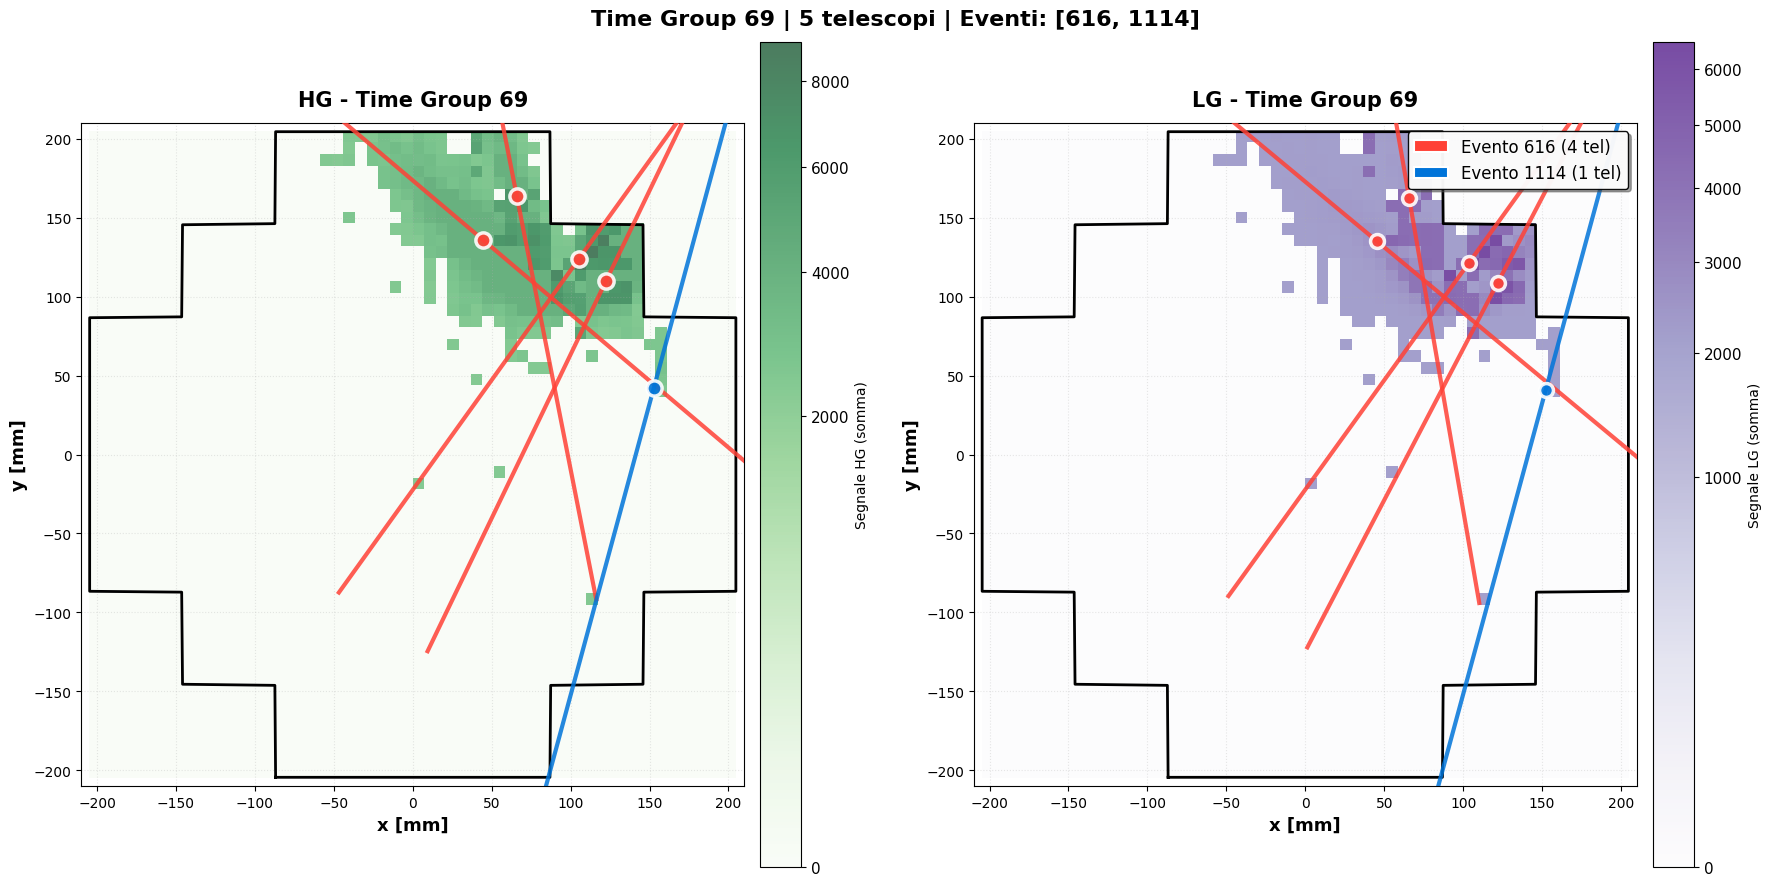

✓ Completato time_group 69
  Rette per evento: {616: 4, 1114: 1}


TIME GROUP 751
Telescopi: 5 | Eventi: [40503 40514] | MCRUN: [220016]


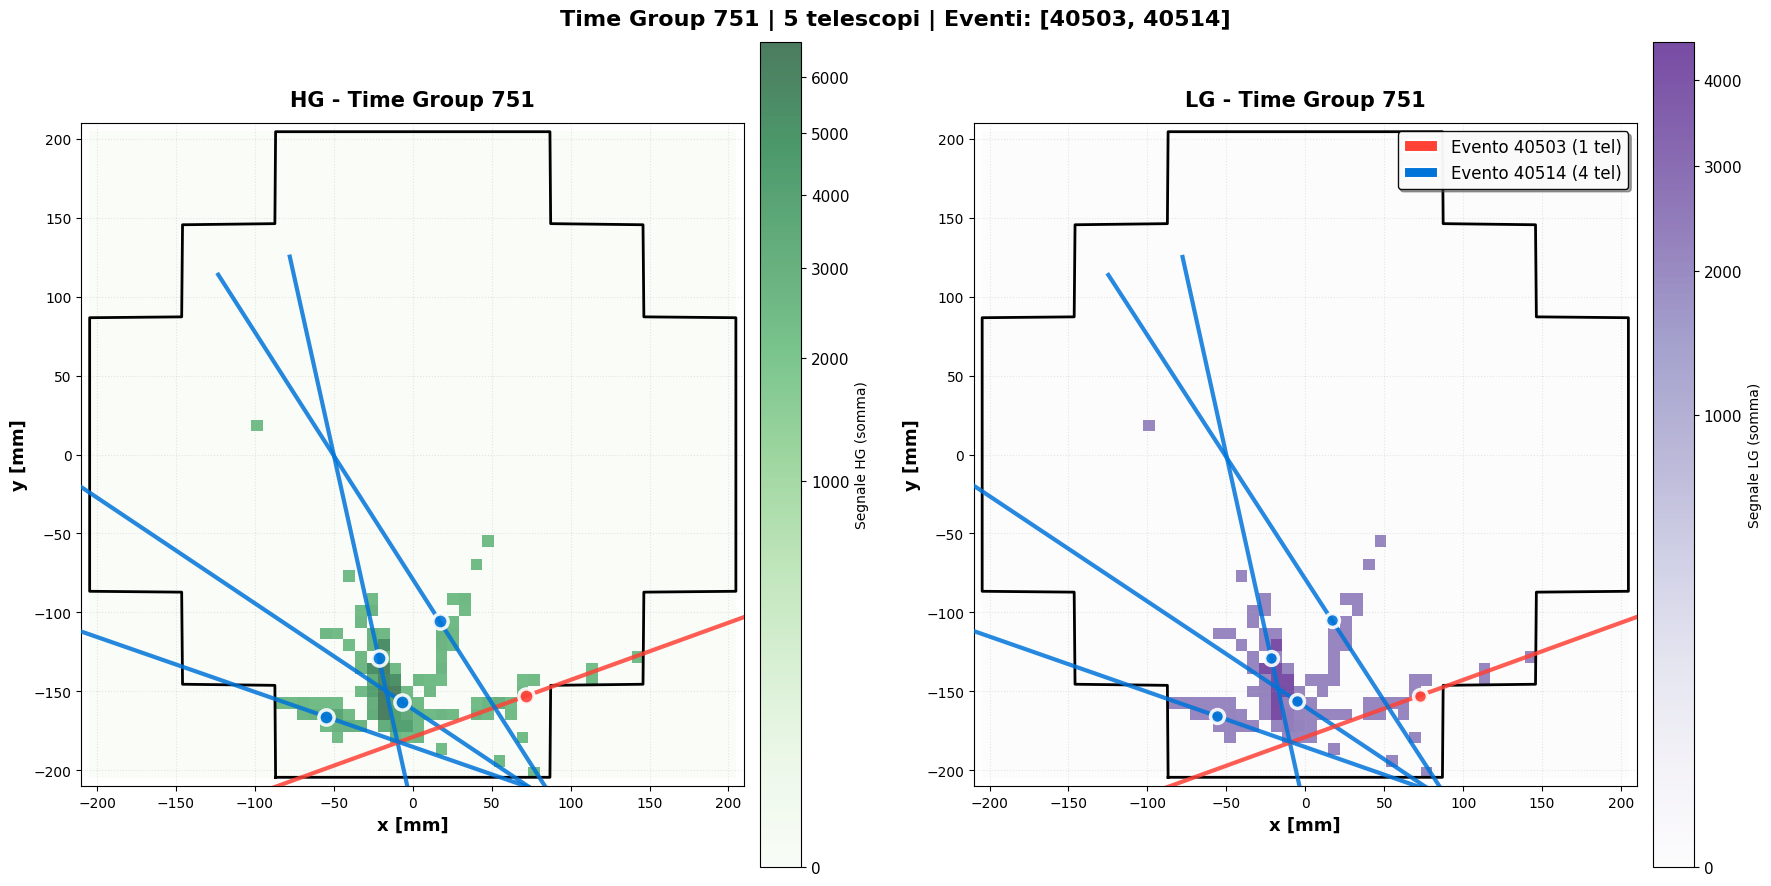

✓ Completato time_group 751
  Rette per evento: {40503: 1, 40514: 4}


TIME GROUP 1681
Telescopi: 4 | Eventi: [3505 3516] | MCRUN: [220035]


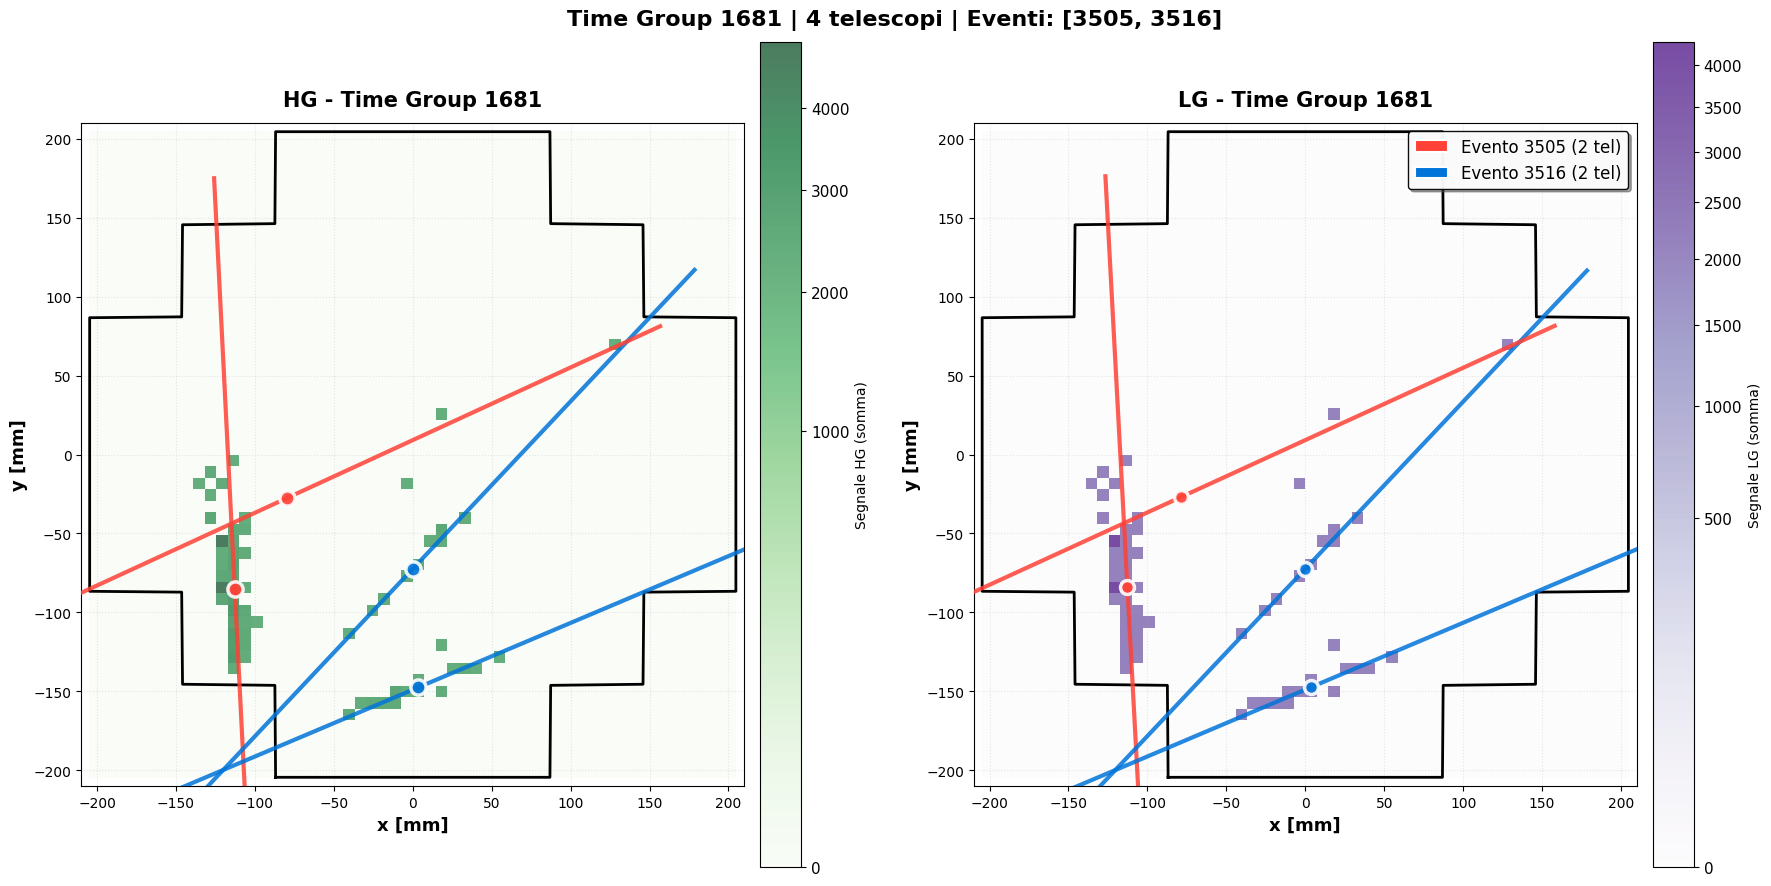

✓ Completato time_group 1681
  Rette per evento: {3505: 2, 3516: 2}



In [150]:

from matplotlib.colors import PowerNorm
xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)
for time_group in df_linked_events['time_group'].drop_duplicates().values[:3]:
    
    # Estrai tutti gli eventi di questo gruppo temporale
    df_window = df_linked_events[df_linked_events['time_group'] == time_group].copy()
    
    # Informazioni sul gruppo
    unique_events = df_window['EVENT'].unique()
    unique_mcruns = df_window['MCRUN'].unique()
    
    print(f"\n{'='*70}")
    print(f"TIME GROUP {time_group}")
    print(f"Telescopi: {len(df_window)} | Eventi: {unique_events} | MCRUN: {unique_mcruns}")
    print(f"{'='*70}")
    
    # Ordina per shape
    df_window = df_window.sort_values(by='shape', ascending=False).reset_index(drop=True)
    
    # Inizializza array per sommare le immagini
    weights_hg = np.zeros_like(np.array(df_window['HG'].iloc[0]))
    weights_lg = np.zeros_like(np.array(df_window['LG'].iloc[0]))
    mask_tot = np.zeros((37, 64), dtype=bool)
    
    # Crea figura side-by-side
    fig, ax = plt.subplots(1, 2, figsize=(18, 9))
    
    # Lunghezza rette
    xmin, xmax = np.min(xfp), np.max(xfp)
    ymin, ymax = np.min(yfp), np.max(yfp)
    diag = np.sqrt((xmax - xmin)**2 + (ymax - ymin)**2)
    L = 0.45 * diag
    
    # Colori per eventi (più vivaci)
    colors = ['#FF4136', '#0074D9', '#2ECC40', '#FF851B']  # rosso, blu, verde, arancione
    event_color_map = {unique_events[i]: colors[i % len(colors)] for i in range(len(unique_events))}
    
    # Liste per contare rette per evento
    rette_per_evento = {ev: 0 for ev in unique_events}
    
    # Itera su tutti i telescopi del gruppo
    for idx, row in df_window.iterrows():
        
        hgev = np.array(row['HG'])
        lgev = np.array(row['LG'])
        ttpev = np.array(row['TTP'])
        
        # mask di pixel buoni
        pxmask = (hgev > 2400) & (ttpev < 255)
        
        if not np.any(pxmask):
            continue
        
        # Somma le immagini
        weights_hg[pxmask] += hgev[pxmask]
        weights_lg[pxmask] += lgev[pxmask]
        mask_tot |= pxmask
        
        # Centroidi
        meanx_hg = np.average(x_pix[pxmask].flatten(), weights=hgev[pxmask].flatten())
        meany_hg = np.average(y_pix[pxmask].flatten(), weights=hgev[pxmask].flatten())
        meanx_lg = np.average(x_pix[pxmask].flatten(), weights=lgev[pxmask].flatten())
        meany_lg = np.average(y_pix[pxmask].flatten(), weights=lgev[pxmask].flatten())
        
        # Covarianze
        cov_hg = np.cov([x_pix[pxmask].flatten(), y_pix[pxmask].flatten()], 
                        aweights=hgev[pxmask].flatten())
        cov_lg = np.cov([x_pix[pxmask].flatten(), y_pix[pxmask].flatten()], 
                        aweights=lgev[pxmask].flatten())
        
        # Parametri ellisse
        l1_hg = (cov_hg[0,0] + cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0] - cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
        
        l1_lg = (cov_lg[0,0] + cov_lg[1,1])/2 + np.sqrt(((cov_lg[0,0] - cov_lg[1,1])/2)**2 + cov_lg[0,1]**2)
        theta_lg = np.arctan2(l1_lg - cov_lg[0,0], cov_lg[0,1])
        
        # Colore basato sull'evento
        color_ev = event_color_map[row['EVENT']]
        rette_per_evento[row['EVENT']] += 1
        
        # ===== HG (sinistra) =====
        ax[0].scatter(meanx_hg, meany_hg, s=120, color=color_ev, 
                      edgecolor='white', linewidth=2.5, zorder=6, alpha=0.9)
        
        x1 = meanx_hg - L * np.cos(theta_hg)
        y1 = meany_hg - L * np.sin(theta_hg)
        x2 = meanx_hg + L * np.cos(theta_hg)
        y2 = meany_hg + L * np.sin(theta_hg)
        ax[0].plot([x1, x2], [y1, y2], color=color_ev, linewidth=3, alpha=0.85, zorder=5)
        
        # ===== LG (destra) =====
        ax[1].scatter(meanx_lg, meany_lg, s=100, color=color_ev, 
                      edgecolor='white', linewidth=2.5, zorder=6, alpha=0.9)
        
        x1 = meanx_lg - L * np.cos(theta_lg)
        y1 = meany_lg - L * np.sin(theta_lg)
        x2 = meanx_lg + L * np.cos(theta_lg)
        y2 = meany_lg + L * np.sin(theta_lg)
        ax[1].plot([x1, x2], [y1, y2], color=color_ev, linewidth=3, alpha=0.85, zorder=5)
    
    # Heatmap somma
    weights_hg = np.array(weights_hg)
    weights_lg = np.array(weights_lg)
    
    h1 = ax[0].hist2d(x_pix[mask_tot].flatten(), y_pix[mask_tot].flatten(),
                      weights=weights_hg[mask_tot].flatten(), 
                      range=((-205, 205), (-205, 205)),
                      bins=7*8, cmap='Greens', alpha=0.7, norm=PowerNorm(0.4))
    
    h2 = ax[1].hist2d(x_pix[mask_tot].flatten(), y_pix[mask_tot].flatten(),
                      weights=weights_lg[mask_tot].flatten(), 
                      range=((-205, 205), (-205, 205)),
                      bins=7*8, cmap='Purples', alpha=0.7, norm=PowerNorm(0.4))
    
    # Footprint camera
    for a in ax:
        a.plot(xfp, yfp, 'k-', linewidth=2, zorder=2)
        a.set_xlim(-210, 210)
        a.set_ylim(-210, 210)
        a.set_aspect('equal')
        a.set_xlabel('x [mm]', fontsize=13, fontweight='bold')
        a.set_ylabel('y [mm]', fontsize=13, fontweight='bold')
        a.grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
    
    ax[0].set_title(f'HG - Time Group {time_group}', fontweight='bold', fontsize=15, pad=12)
    ax[1].set_title(f'LG - Time Group {time_group}', fontweight='bold', fontsize=15, pad=12)
    
    # Colorbar
    cbar1 = fig.colorbar(h1[3], ax=ax[0], label='Segnale HG (somma)', pad=0.02)
    cbar2 = fig.colorbar(h2[3], ax=ax[1], label='Segnale LG (somma)', pad=0.02)
    cbar1.ax.tick_params(labelsize=11)
    cbar2.ax.tick_params(labelsize=11)
    
    # Legenda eventi
    from matplotlib.patches import Patch
    legend_elements = [
        Patch(facecolor=event_color_map[ev], edgecolor='white', linewidth=1.5,
              label=f'Evento {ev} ({rette_per_evento[ev]} tel)')
        for ev in unique_events
    ]
    ax[1].legend(handles=legend_elements, loc='upper right', fontsize=12, 
                 framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
    
    plt.suptitle(f'Time Group {time_group} | {len(df_window)} telescopi | Eventi: {list(unique_events)}',
                 fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Completato time_group {time_group}")
    print(f"  Rette per evento: {rette_per_evento}\n")

In [151]:
#inizio l'analisi con il mio metodo
# ======================= FUNZIONI GEOMETRICHE =======================

def intersection(p1, d1, p2, d2, eps_ang=1e-1, eps_det=1e-6):
    """
    p1, p2 = punti (2,)
    d1, d2 = direzioni (2,)
    """

    # --- controllo quasi-parallelismo ---
    det_dir = d1[0]*d2[1] - d1[1]*d2[0]
    if abs(det_dir) < eps_ang:        # <<< taglio fisico
        return None

    A = np.array([d1, -d2]).T
    b = p2 - p1

    detA = np.linalg.det(A)
    if abs(detA) < eps_det:           # <<< sicurezza numerica
        return None

    t = np.linalg.solve(A, b)[0]
    return p1 + t * d1
def d_punto_retta(P, p0, d):
    norm_d = np.linalg.norm(d)
    if norm_d == 0:
        return np.nan
    d_unit = d / norm_d
    v = P - p0
    return abs(v[0] * d_unit[1] - v[1] * d_unit[0])
def d_punto_retta_vec(P, p0, d):
    """
    distanza di N rette da un punto
    """
    norm_d = np.linalg.norm(d, axis=1)
    mask = norm_d > 0
    d_unit = np.zeros_like(d)
    d_unit[mask] = d[mask] / norm_d[mask, None]
    v = P - p0
    return np.abs(v[:, 0] * d_unit[:, 1] - v[:, 1] * d_unit[:, 0])


In [152]:



def principal_axis(cov):
            l1 = (cov[0,0] + cov[1,1])/2 + np.sqrt(
                ((cov[0,0] - cov[1,1])/2)**2 + cov[0,1]**2)
            theta = np.arctan2(l1 - cov[0,0], cov[0,1])
            return l1, theta
#raccolgo i dati delle rette divisi per ogni (event,mcrun)
#df_all_sorted=df_all_sorted[df_all_sorted["shape"]>5.16e6]
#df_all_sorted=df_all_sorted[df_all_sorted["num_tel"]>=3]



xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

results = []

for time_group, df_evt in df_linked_events.groupby('time_group'):
    
    for iv, row in df_evt.iterrows():

        itel = row["TEL_ID"]
        event = row["EVENT"]     
        mcrun = row["MCRUN"]     
        
        hgev = np.array(row["HG"])
        lgev = np.array(row["LG"])
        ttpev = np.array(row["TTP"])

        # filtro temporale
        pxmask = (hgev > 2400) & (ttpev < 255)
        if np.sum(pxmask) < 2:
            continue
        
        # SIGMA-CLIPPING
        xx = x_pix[pxmask].flatten()
        yy = y_pix[pxmask].flatten()
        w_hg = hgev[pxmask].flatten()
        w_lg = lgev[pxmask].flatten()

        mx0 = np.average(xx, weights=w_hg)
        my0 = np.average(yy, weights=w_hg)

        r = np.sqrt((xx - mx0)**2 + (yy - my0)**2)

        r_clip, low, high = sc.sigmaclip(r, low=2., high=2.)
        keep = (r >= low) & (r <= high)

        xx_sc = xx[keep]
        yy_sc = yy[keep]
        w_hg_sc = w_hg[keep]
        w_lg_sc = w_lg[keep]
        
        # ---------- centroidi ----------
        meanx_hg = np.average(xx_sc, weights=w_hg_sc)
        meany_hg = np.average(yy_sc, weights=w_hg_sc)

        meanx_lg = np.average(xx_sc, weights=w_lg_sc)
        meany_lg = np.average(yy_sc, weights=w_lg_sc)

        # ---------- covarianze ----------
        cov_hg = np.cov([xx_sc, yy_sc], aweights=w_hg_sc)
        cov_lg = np.cov([xx_sc, yy_sc], aweights=w_lg_sc)

        l1_hg, theta_hg = principal_axis(cov_hg)
        l1_lg, theta_lg = principal_axis(cov_lg)

        results.append({
            "time_group": int(time_group),
            "event": int(event),      
            "mcrun": int(mcrun),      
            "HG": {
                "p0": np.array([meanx_hg, meany_hg]),
                "d":  np.array([np.cos(theta_hg), np.sin(theta_hg)]),
                "l1": l1_hg,
                "tel": int(itel)       
            },
            "LG": {
                "p0": np.array([meanx_lg, meany_lg]),
                "d":  np.array([np.cos(theta_lg), np.sin(theta_lg)]),
                "l1": l1_lg,
                "tel": int(itel)       
            }
        })

print(f"Creati {len(results)} risultati")
dfR = pd.DataFrame(results)
print(dfR.columns)
print(len(dfR["time_group"].unique()))

Creati 57 risultati
Index(['time_group', 'event', 'mcrun', 'HG', 'LG'], dtype='object')
12


In [153]:
# Time groups in df_linked_events
time_groups_linked = set(df_linked_events['time_group'].unique())

# Time groups in dfR
time_groups_dfR = set(dfR['time_group'].unique())

# Time groups mancanti (presenti in df_linked_events ma non in dfR)
missing_time_groups = time_groups_linked - time_groups_dfR

print(f"Time groups in df_linked_events: {len(time_groups_linked)}")
print(f"Time groups in dfR: {len(time_groups_dfR)}")
print(f"Time groups mancanti: {len(missing_time_groups)}")
print(f"\nLista time groups mancanti: {sorted(missing_time_groups)}")

# Analizza perché sono mancanti
print(f"\n{'='*70}")
print("ANALISI TIME GROUPS MANCANTI")
print(f"{'='*70}")

for tg in sorted(missing_time_groups):
    df_missing = df_linked_events[df_linked_events['time_group'] == tg]
    
    # Conta quanti avevano troppo pochi pixel
    n_total = len(df_missing)
    
    print(f"\nTime Group {tg}:")
    print(f"  Telescopi totali: {n_total}")
    print(f"  Eventi: {df_missing['EVENT'].unique()}")
    print(f"  MCRUN: {df_missing['MCRUN'].unique()}")
    
    # Verifica manualmente quanti avrebbero passato il filtro pxmask
    n_passed = 0
    for _, row in df_missing.iterrows():
        hgev = np.array(row["HG"])
        ttpev = np.array(row["TTP"])
        pxmask = (hgev > 2400) & (ttpev < 255)
        if np.sum(pxmask) >= 2:
            n_passed += 1
    
    print(f"  Telescopi che passano pxmask (>2 pixel): {n_passed}")
    print(f"  Telescopi filtrati: {n_total - n_passed}")

Time groups in df_linked_events: 12
Time groups in dfR: 12
Time groups mancanti: 0

Lista time groups mancanti: []

ANALISI TIME GROUPS MANCANTI


In [154]:
# ======================= CALCOLO INTERSEZIONI =======================
'''
inters_hg = []
inters_lg = []
dfR = pd.DataFrame(results)
print(dfR.head(10))

for time_group, df_evt in dfR.groupby('time_group'):

    rette_hg = df_evt["HG"].values
    rette_lg = df_evt["LG"].values

    # ---------- HG ----------
    for i in range(len(rette_hg)):
        for j in range(i+1, len(rette_hg)):

            if rette_hg[i]["tel"] == rette_hg[j]["tel"]:
                continue

            d1 = rette_hg[i]["d"]
            d2 = rette_hg[j]["d"]

            P = intersection(rette_hg[i]["p0"], d1,rette_hg[j]["p0"], d2)

            if P is None:
                continue

            inters_hg.append({
                "time_group":time_group,
                "event": event,
                "mcrun": mcrun,
                "d1": d1,
                "d2": d2,
                "P": P,
                "pair": (i, j)
            })

    # ---------- LG ----------
    for i in range(len(rette_lg)):
        for j in range(i+1, len(rette_lg)):

            if rette_lg[i]["tel"] == rette_lg[j]["tel"]:
                continue

            d1 = rette_lg[i]["d"]
            d2 = rette_lg[j]["d"]

            P = intersection(
                rette_lg[i]["p0"], d1,
                rette_lg[j]["p0"], d2
            )

            if P is None:
                continue
              
            inters_lg.append({
                "time_group":time_group,
                "event_arr": event,
                "mcrun_arr": mcrun,
                "d1": d1,
                "d2": d2,
                "P": P,
                "pair": (i, j)
            })

df_int_hg = pd.DataFrame(inters_hg)
df_int_lg = pd.DataFrame(inters_lg)
'''
inters_hg = []
inters_lg = []
dfR = pd.DataFrame(results)
print(dfR.head(10))

for time_group, df_evt in dfR.groupby('time_group'):

    rette_hg = df_evt["HG"].values
    rette_lg = df_evt["LG"].values

    # ---------- HG ----------
    for i in range(len(rette_hg)):
        for j in range(i+1, len(rette_hg)):

            d1 = rette_hg[i]["d"]
            d2 = rette_hg[j]["d"]

            P = intersection(rette_hg[i]["p0"], d1, rette_hg[j]["p0"], d2)

            if P is None:
                continue

            inters_hg.append({
                "time_group": time_group,
                "d1": d1,
                "d2": d2,
                "P": P,
                "pair": (i, j)
            })

    # ---------- LG ----------
    for i in range(len(rette_lg)):
        for j in range(i+1, len(rette_lg)):

            d1 = rette_lg[i]["d"]
            d2 = rette_lg[j]["d"]

            P = intersection(rette_lg[i]["p0"], d1, rette_lg[j]["p0"], d2)

            if P is None:
                continue
              
            inters_lg.append({
                "time_group": time_group,
                "d1": d1,
                "d2": d2,
                "P": P,
                "pair": (i, j)
            })

df_int_hg = pd.DataFrame(inters_hg)
df_int_lg = pd.DataFrame(inters_lg)
#'''
print(f"\nIntersezioni HG: {len(df_int_hg)}")
print(f"Intersezioni LG: {len(df_int_lg)}")
print(len(df_int_hg["time_group"].unique()))

   time_group  event   mcrun  \
0          69    616  220001   
1          69    616  220001   
2          69    616  220001   
3          69    616  220001   
4          69   1114  220001   
5         751  40503  220016   
6         751  40514  220016   
7         751  40514  220016   
8         751  40514  220016   
9         751  40514  220016   

                                                  HG  \
0  {'p0': [65.63939970668753, 167.05216887771314]...   
1  {'p0': [113.70207149634656, 135.80215284482463...   
2  {'p0': [123.20630575243992, 110.67454264780072...   
3  {'p0': [45.236455423203005, 134.98406770368663...   
4  {'p0': [157.77733909154213, 59.863882173656854...   
5  {'p0': [65.5738406213427, -155.19758524665747]...   
6  {'p0': [22.77594674151074, -117.25640423007624...   
7  {'p0': [-20.487972712770365, -131.531076906024...   
8  {'p0': [-10.337658242158616, -160.197176225634...   
9  {'p0': [-53.486499324910795, -166.449952191628...   

                              

In [155]:
for tg, df_evt in dfR.groupby("time_group"):
    print(f"time_group{tg} ha {len(df_evt)} rette, telescopi: {df_evt['HG'].apply(lambda r: r['tel']).tolist()}")

print("eventi temporali: ",len(dfR["time_group"].unique()))
n_tel_per_event = dfR.groupby("time_group").apply(
    lambda g: pd.unique(
        np.concatenate([g['HG'].apply(lambda x: x['tel']),
                        g['LG'].apply(lambda x: x['tel'])])
    ).size
)

# numero di eventi con un solo telescopio
n_eventi_un_tel = (n_tel_per_event == 1).sum()
print("eventi temporali che hanno un telescopio solo:", n_eventi_un_tel)
duplicati_count = 0
for tg, df_evt in dfR.groupby("time_group"):
    telescopi = df_evt['HG'].apply(lambda r: r['tel']).tolist()
    if len(telescopi) != len(set(telescopi)):
        duplicati_count += 1

print(f"Time_group con telescopi duplicati: {duplicati_count}")

time_group69 ha 5 rette, telescopi: [7, 6, 8, 9, 1]
time_group751 ha 5 rette, telescopi: [9, 2, 3, 5, 6]
time_group1681 ha 4 rette, telescopi: [3, 5, 7, 9]
time_group1959 ha 2 rette, telescopi: [9, 2]
time_group2665 ha 7 rette, telescopi: [1, 2, 4, 3, 5, 6, 9]
time_group3031 ha 3 rette, telescopi: [2, 3, 7]
time_group3061 ha 5 rette, telescopi: [1, 2, 7, 8, 9]
time_group3165 ha 4 rette, telescopi: [1, 2, 3, 5]
time_group3246 ha 6 rette, telescopi: [4, 7, 2, 3, 5, 6]
time_group3572 ha 2 rette, telescopi: [1, 8]
time_group3855 ha 6 rette, telescopi: [3, 5, 6, 8, 4, 7]
time_group4526 ha 8 rette, telescopi: [8, 2, 3, 4, 5, 6, 7, 9]
eventi temporali:  12
eventi temporali che hanno un telescopio solo: 0
Time_group con telescopi duplicati: 0


/tmp/ipykernel_652027/1765511758.py:5: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  n_tel_per_event = dfR.groupby("time_group").apply(


In [156]:
from sklearn.cluster import DBSCAN
epsilon = 295
min_samples = 1

# ======================= HG =======================
dist_hg = []

for time_group, df_evt in df_int_hg.groupby("time_group"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    # clustering DBSCAN
    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    # Rette del time_group
    dfR_evt = dfR[dfR["time_group"] == time_group]
    
    # CREA DIZIONARIO tel -> (event, mcrun)
    tel_to_event = {}
    for _, row in dfR_evt.iterrows():
        tel_id = row["HG"]["tel"]
        tel_to_event[tel_id] = (row["event"], row["mcrun"])
    
    # Estrai parametri rette
    p0 = np.vstack([r["p0"] for r in dfR_evt["HG"]])
    d = np.vstack([r["d"] for r in dfR_evt["HG"]])
    tel = np.array([r["tel"] for r in dfR_evt["HG"]])

    # ciclo cluster
    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        # ---------- calcolo pesi angolari ----------
        w = []
        for _, row in dfP.iterrows():
            d1 = row["d1"]
            d2 = row["d2"]
            w.append((d1[0]*d2[1] - d1[1]*d2[0])**2)   # sin^2(theta)

        w = np.array(w)

        # ---------- media pesata e semplice ----------
        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median = d_punto_retta_vec(P_median, p0, d)
        
        # Per ogni retta, prendi il SUO event e mcrun
        for t, dm_s, dm_w, dmed in zip(tel, dist_mean_simple, dist_mean_weighted, dist_median):
            
            # Estrai event e mcrun SPECIFICI di questa retta
            evt, mc = tel_to_event[int(t)]
            
            dist_hg.append({
                "time_group": int(time_group),
                "event": int(evt),
                "mcrun": int(mc),
                "cluster": int(lab),
                "tel": int(t),
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": float(dm_s),
                "d_weight": float(dm_w),
                "d_median": float(dmed)
            })

df_dist_hg = pd.DataFrame(dist_hg)


# ======================= LG =======================
dist_lg = []

for time_group, df_evt in df_int_lg.groupby("time_group"):

    P = np.vstack(df_evt["P"].values)
    if P.shape[0] < min_samples:
        continue

    labels = DBSCAN(eps=epsilon, min_samples=min_samples).fit_predict(P)
    cl_labels = set(labels) - {-1}
    if not cl_labels:
        continue

    # Rette del time_group
    dfR_evt = dfR[dfR["time_group"] == time_group]
    
    # CREA DIZIONARIO tel -> (event, mcrun)
    tel_to_event = {}
    for _, row in dfR_evt.iterrows():
        tel_id = row["LG"]["tel"]
        tel_to_event[tel_id] = (row["event"], row["mcrun"])
    
    # Estrai parametri rette
    p0 = np.vstack([r["p0"] for r in dfR_evt["LG"]])
    d = np.vstack([r["d"] for r in dfR_evt["LG"]])
    tel = np.array([r["tel"] for r in dfR_evt["LG"]])

    for lab in cl_labels:
        Pcl = P[labels == lab]
        dfP = df_evt[labels == lab]

        w = []
        for _, row in dfP.iterrows():
            d1 = row["d1"]
            d2 = row["d2"]
            w.append((d1[0]*d2[1] - d1[1]*d2[0])**2)

        w = np.array(w)

        P_simple = np.mean(Pcl, axis=0)
        P_weight = np.average(Pcl, axis=0, weights=w)
        P_median = np.median(Pcl, axis=0)

        dist_mean_simple = d_punto_retta_vec(P_simple, p0, d)
        dist_mean_weighted = d_punto_retta_vec(P_weight, p0, d)
        dist_median = d_punto_retta_vec(P_median, p0, d)
        
        # Per ogni retta, prendi il SUO event e mcrun
        for t, dm_s, dm_w, dmed in zip(tel, dist_mean_simple, dist_mean_weighted, dist_median):
            
            # Estrai event e mcrun SPECIFICI di questa retta
            evt, mc = tel_to_event[int(t)]
            
            dist_lg.append({
                "time_group": int(time_group),
                "event": int(evt),
                "mcrun": int(mc),
                "cluster": int(lab),
                "tel": int(t),
                "P_simple": P_simple.copy(),
                "P_weight": P_weight.copy(),
                "P_median": P_median.copy(),
                "d_mean_simple": float(dm_s),
                "d_weight": float(dm_w),
                "d_median": float(dmed)
            })

df_dist_lg = pd.DataFrame(dist_lg)
print(len(df_dist_hg["time_group"].unique()))
print(len(df_dist_lg["time_group"].unique()))
# Assicurati che i tipi siano uguali
df_linked_events['TEL_ID'] = df_linked_events['TEL_ID'].astype(int)
df_linked_events['EVENT'] = df_linked_events['EVENT'].astype(int)
df_linked_events['MCRUN'] = df_linked_events['MCRUN'].astype(int)

df_dist_hg['tel'] = df_dist_hg['tel'].astype(int)
df_dist_hg['event'] = df_dist_hg['event'].astype(int)
df_dist_hg['mcrun'] = df_dist_hg['mcrun'].astype(int)
######## AGGIUNGO PUNTO- MEDIANA#################################################
# Rinomina le colonne in df_dist_hg per farle coincidere
df_dist_hg_renamed = df_dist_hg.rename(columns={
    'tel': 'TEL_ID',
    'event': 'EVENT',
    'mcrun': 'MCRUN'
})

# Merge per aggiungere P_median, P_weight, P_simple
df_linked_events = pd.merge(
    df_linked_events,
    df_dist_hg_renamed[['time_group', 'TEL_ID', 'EVENT', 'MCRUN', 'P_median', 'P_weight', 'P_simple']],
    on=['time_group', 'TEL_ID', 'EVENT', 'MCRUN'],
    how='left'
)
#print(df_linked_events[['time_group', 'P_median']][10:30])
print(f"NaN in P_median: {df_linked_events['P_median'].isna().sum()}/{len(df_linked_events)}")


# Vedi quali righe hanno NaN
df_nan = df_linked_events[df_linked_events['P_median'].isna()]
print(f"\nRighe con NaN:\n{df_nan[['time_group', 'TEL_ID', 'EVENT', 'MCRUN']]}")

print(f"NaN in P_median: {df_linked_events['P_median'].isna().sum()}/{len(df_linked_events)}")


# Vedi quali righe hanno NaN
print(f"NaN in P_weight: {df_linked_events['P_weight'].isna().sum()}/{len(df_linked_events)}")
df_nan1 = df_linked_events[df_linked_events['P_weight'].isna()]
print(f"\nRighe con NaN:\n{df_nan1[['time_group', 'TEL_ID', 'EVENT', 'MCRUN']]}")

12
12
NaN in P_median: 0/79

Righe con NaN:
Empty DataFrame
Columns: [time_group, TEL_ID, EVENT, MCRUN]
Index: []
NaN in P_median: 0/79
NaN in P_weight: 0/79

Righe con NaN:
Empty DataFrame
Columns: [time_group, TEL_ID, EVENT, MCRUN]
Index: []


In [157]:
# Verifica se queste combinazioni esistono in df_dist_hg
missing_combinations = [
    (1669, 9, 42709, 220034),
    (3165, 1, 43007, 220267),
    (3246, 4, 41912, 220269),
    (3855, 6, 40514, 220283),
    (4526, 8, 12808, 220297)
]

print("Verifica delle combinazioni mancanti in df_dist_hg:\n")
for tg, tel, evt, mcrun in missing_combinations:
    match = df_dist_hg[
        (df_dist_hg['time_group'] == tg) & 
        (df_dist_hg['tel'] == tel) & 
        (df_dist_hg['event'] == evt) & 
        (df_dist_hg['mcrun'] == mcrun)
    ]
    print(f"time_group={tg}, tel={tel}, event={evt}, mcrun={mcrun}: {len(match)} match")
    
    # Vedi se esiste almeno il time_group
    tg_match = df_dist_hg[df_dist_hg['time_group'] == tg]
    print(f"  -> Telescopi in questo time_group: {tg_match['tel'].unique() if len(tg_match) > 0 else 'NESSUNO'}\n")

Verifica delle combinazioni mancanti in df_dist_hg:

time_group=1669, tel=9, event=42709, mcrun=220034: 0 match
  -> Telescopi in questo time_group: NESSUNO

time_group=3165, tel=1, event=43007, mcrun=220267: 1 match
  -> Telescopi in questo time_group: [1 2 3 5]

time_group=3246, tel=4, event=41912, mcrun=220269: 3 match
  -> Telescopi in questo time_group: [4 7 2 3 5 6]

time_group=3855, tel=6, event=40514, mcrun=220283: 2 match
  -> Telescopi in questo time_group: [3 5 6 8 4 7]

time_group=4526, tel=8, event=12808, mcrun=220297: 1 match
  -> Telescopi in questo time_group: [8 2 3 4 5 6 7 9]



In [158]:
'''
for fevent, df_evt in dfR.groupby("time_group"):
    print(f"time_group{fevent} ha {len(df_evt)} rette, telescopi: {df_evt['HG'].apply(lambda r: r['tel']).tolist()}")
#dfR = dfR.groupby("time_group").filter(lambda df_evt: df_evt['HG'].apply(lambda r: r['tel']).nunique() >= 2)
print("filtraggio")
for fevent, df_evt in dfR.groupby("time_group"):
    print(f"time_group{fevent} ha {len(df_evt)} rette, telescopi: {df_evt['HG'].apply(lambda r: r['tel']).tolist()}")
    
print(len(df_linked_events["time_group"].unique()))
'''
for fevent, df_evt in dfR.groupby("time_group"):
    n_telescopi = len(df_evt)  # Numero di righe = numero di telescopi
    telescopi = df_evt['HG'].apply(lambda r: r['tel']).tolist()
    print(f"time_group {fevent} ha {n_telescopi} rette, telescopi: {telescopi}")

print("\nFiltraggio")

for fevent, df_evt in dfR.groupby("time_group"):
    n_telescopi = len(df_evt)
    telescopi = df_evt['HG'].apply(lambda r: r['tel']).tolist()
    print(f"time_group {fevent} ha {n_telescopi} rette, telescopi: {telescopi}")

# Numero massimo di telescopi in un singolo time_group
max_telescopi_per_group = dfR.groupby("time_group").size().max()
print(f"\nMax telescopi in un time_group: {max_telescopi_per_group}")

# Oppure per df_linked_events
max_telescopi_linked = df_linked_events.groupby("time_group").size().max()
print(f"Max telescopi in df_linked_events: {max_telescopi_linked}")

# Per vedere quale time_group ha il massimo
telescopi_counts = dfR.groupby("time_group").size()
time_group_max = telescopi_counts.idxmax()
print(f"Time_group con più telescopi: {time_group_max} ({telescopi_counts.max()} telescopi)")

time_group 69 ha 5 rette, telescopi: [7, 6, 8, 9, 1]
time_group 751 ha 5 rette, telescopi: [9, 2, 3, 5, 6]
time_group 1681 ha 4 rette, telescopi: [3, 5, 7, 9]
time_group 1959 ha 2 rette, telescopi: [9, 2]
time_group 2665 ha 7 rette, telescopi: [1, 2, 4, 3, 5, 6, 9]
time_group 3031 ha 3 rette, telescopi: [2, 3, 7]
time_group 3061 ha 5 rette, telescopi: [1, 2, 7, 8, 9]
time_group 3165 ha 4 rette, telescopi: [1, 2, 3, 5]
time_group 3246 ha 6 rette, telescopi: [4, 7, 2, 3, 5, 6]
time_group 3572 ha 2 rette, telescopi: [1, 8]
time_group 3855 ha 6 rette, telescopi: [3, 5, 6, 8, 4, 7]
time_group 4526 ha 8 rette, telescopi: [8, 2, 3, 4, 5, 6, 7, 9]

Filtraggio
time_group 69 ha 5 rette, telescopi: [7, 6, 8, 9, 1]
time_group 751 ha 5 rette, telescopi: [9, 2, 3, 5, 6]
time_group 1681 ha 4 rette, telescopi: [3, 5, 7, 9]
time_group 1959 ha 2 rette, telescopi: [9, 2]


time_group 2665 ha 7 rette, telescopi: [1, 2, 4, 3, 5, 6, 9]
time_group 3031 ha 3 rette, telescopi: [2, 3, 7]
time_group 3061 ha 5 rette, telescopi: [1, 2, 7, 8, 9]
time_group 3165 ha 4 rette, telescopi: [1, 2, 3, 5]
time_group 3246 ha 6 rette, telescopi: [4, 7, 2, 3, 5, 6]
time_group 3572 ha 2 rette, telescopi: [1, 8]
time_group 3855 ha 6 rette, telescopi: [3, 5, 6, 8, 4, 7]
time_group 4526 ha 8 rette, telescopi: [8, 2, 3, 4, 5, 6, 7, 9]

Max telescopi in un time_group: 8
Max telescopi in df_linked_events: 18
Time_group con più telescopi: 4526 (8 telescopi)


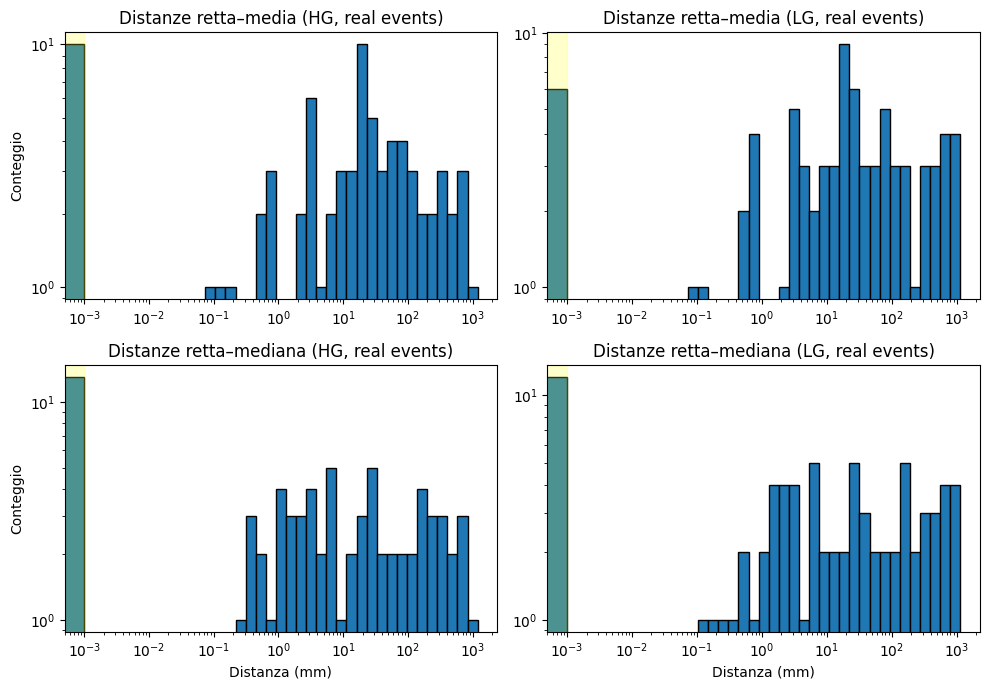

Index(['TIME_NS', 'TIME_S', 'TIME_ABS', 'EVENT', 'MCRUN', 'TEL_ID', 'num_tel',
       'HG', 'LG', 'TTP', 'shape', 'n_valid_pixels', 'dt', 'new_group',
       'time_group', 'same_event', 'same_mcrun', 'same_event_mcrun',
       'window_type', 'P_median', 'P_weight', 'P_simple'],
      dtype='object')


In [159]:

# ===================== ESTRAZIONE DISTANZE =====================
d_mean_hg   = df_dist_hg["d_weight"].values
d_median_hg = df_dist_hg["d_median"].values
d_mean_lg  = df_dist_lg["d_weight"].values
d_median_lg = df_dist_lg["d_median"].values

# filtro valori validi (>0 e finiti)
d_mean_hg   = d_mean_hg[np.isfinite(d_mean_hg) & (d_mean_hg > 0)]
d_median_hg = d_median_hg[np.isfinite(d_median_hg) & (d_median_hg > 0)]
d_mean_lg   = d_mean_lg[np.isfinite(d_mean_lg) & (d_mean_lg > 0)]
d_median_lg = d_median_lg[np.isfinite(d_median_lg) & (d_median_lg > 0)]

# -------------------- BINS LOGARITMICI SEPARATI --------------------
def smart_bins(data, n_bins=40, zero_threshold=0.001):
    """Crea bins logaritmici + bin speciale per valori ~0"""
    bin_zero = [0, zero_threshold]
    log_bins = np.logspace(np.log10(zero_threshold), np.log10(data.max()*1.1), n_bins)
    return np.unique(np.concatenate([bin_zero, log_bins]))

bins_mean_hg   = smart_bins(d_mean_hg)
bins_median_hg = smart_bins(d_median_hg)
bins_mean_lg   = smart_bins(d_mean_lg)
bins_median_lg = smart_bins(d_median_lg)

# ===================== PLOT =====================
fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharex=False, sharey=False)

# -------------------- HG --------------------
axes[0,0].hist(d_mean_hg, bins=bins_mean_hg, edgecolor='black')
axes[0,0].set_title("Distanze retta–media (HG, real events)")
axes[0,0].set_ylabel("Conteggio")

axes[1,0].hist(d_median_hg, bins=bins_median_hg, edgecolor='black')
axes[1,0].set_title("Distanze retta–mediana (HG, real events)")
axes[1,0].set_ylabel("Conteggio")
axes[1,0].set_xlabel("Distanza (mm)")

# -------------------- LG --------------------
axes[0,1].hist(d_mean_lg, bins=bins_mean_lg, edgecolor='black')
axes[0,1].set_title("Distanze retta–media (LG, real events)")

axes[1,1].hist(d_median_lg, bins=bins_median_lg, edgecolor='black')
axes[1,1].set_title("Distanze retta–mediana (LG, real events)")
axes[1,1].set_xlabel("Distanza (mm)")

# scala log su entrambi gli assi
for ax in axes.flat:
    ax.axvspan(0, 0.001, alpha=0.2, color='yellow')
    ax.set_xscale("log")
    ax.set_yscale("log")

plt.tight_layout()
plt.show()
print(df_linked_events.columns)

In [160]:
# ======================= ASSEGNAZIONE CLUSTER PER HG =======================

def assign_clusters(df_dist, threshold=60):
    """
    Assegna ogni retta al cluster più vicino se distanza <= threshold.
    Altrimenti marca come non assegnata.
    """
    results = []
    
    # Raggruppa per (time_group, ogni combinazione è una retta unica######################################
    for (tg, tel), group in df_dist.groupby(['time_group', 'tel']):
        
        # Trova il cluster con distanza minima
        idx_min = group['d_median'].idxmin()
        min_dist = group.loc[idx_min, 'd_median']
        best_cluster = group.loc[idx_min, 'cluster']
        
        # Prendi le altre info (event, mcrun sono uguali per questa retta)
        event = group.loc[idx_min, 'event']
        mcrun = group.loc[idx_min, 'mcrun']
        P_median = group.loc[idx_min, 'P_median']
        
        # Assegna o marca come non assegnata
        if min_dist <= threshold:
            assigned_cluster = best_cluster
            is_assigned = True
        else:
            assigned_cluster = -1  # -1 indica "non assegnato"
            is_assigned = False
        if isinstance(event, np.ndarray):
            event = int(event[0]) if len(event) > 0 else -1
        else:
            event = int(event)
            
        if isinstance(mcrun, np.ndarray):
            mcrun = int(mcrun[0]) if len(mcrun) > 0 else -1
        else:
            mcrun = int(mcrun)
        results.append({
           
            'time_group': int(tg),
            'tel': int(tel),
            'event': int(event) if event is not None else -1,
            'mcrun': int(mcrun) if mcrun is not None else -1,
            'assigned_cluster': assigned_cluster,
            'is_assigned': is_assigned,
            'min_distance': min_dist,
            'n_clusters_available': len(group)  # quanti cluster erano disponibili
        })
    
    return pd.DataFrame(results)

# Applica l'assegnazione
df_assigned_hg = assign_clusters(df_dist_hg, threshold=60)
df_assigned_lg = assign_clusters(df_dist_lg, threshold=60)

# ======================= STATISTICHE =======================

print("="*70)
print("HG - Statistiche assegnazione")
print("="*70)
print(f"Rette totali: {len(df_assigned_hg)}")
print(f"Rette assegnate: {df_assigned_hg['is_assigned'].sum()}")
print(f"Rette non assegnate: {(~df_assigned_hg['is_assigned']).sum()}")
print(f"Percentuale assegnate: {100*df_assigned_hg['is_assigned'].mean():.1f}%")
print(f"\nDistribuzione cluster assegnati:")
print(df_assigned_hg[df_assigned_hg['is_assigned']]['assigned_cluster'].value_counts().sort_index())

print("\n" + "="*70)
print("LG - Statistiche assegnazione")
print("="*70)
print(f"Rette totali: {len(df_assigned_lg)}")
print(f"Rette assegnate: {df_assigned_lg['is_assigned'].sum()}")
print(f"Rette non assegnate: {(~df_assigned_lg['is_assigned']).sum()}")
print(f"Percentuale assegnate: {100*df_assigned_lg['is_assigned'].mean():.1f}%")
print(f"\nDistribuzione cluster assegnati:")
print(df_assigned_lg[df_assigned_lg['is_assigned']]['assigned_cluster'].value_counts().sort_index())

# ======================= VISUALIZZA ESEMPI =======================

print("\n" + "="*70)
print("Esempi HG:")
print("="*70)
print(df_assigned_hg.head(10))

print("\n" + "="*70)
print("Esempi di rette NON assegnate (HG):")
print("="*70)
print(df_assigned_hg[~df_assigned_hg['is_assigned']].head(5))
print("yyy")
print(len(df_assigned_hg["time_group"].unique()))
print(len(df_assigned_lg["time_group"].unique()))

HG - Statistiche assegnazione
Rette totali: 57
Rette assegnate: 53
Rette non assegnate: 4
Percentuale assegnate: 93.0%

Distribuzione cluster assegnati:
assigned_cluster
0    47
1     5
2     1
Name: count, dtype: int64

LG - Statistiche assegnazione
Rette totali: 57
Rette assegnate: 54
Rette non assegnate: 3
Percentuale assegnate: 94.7%

Distribuzione cluster assegnati:
assigned_cluster
0    46
1     6
2     2
Name: count, dtype: int64

Esempi HG:
   time_group  tel  event   mcrun  assigned_cluster  is_assigned  \
0          69    1   1114  220001                 0         True   
1          69    6    616  220001                 0         True   
2          69    7    616  220001                 0         True   
3          69    8    616  220001                 0         True   
4          69    9    616  220001                 0         True   
5         751    2  40514  220016                 0         True   
6         751    3  40514  220016                 0         True   
7  

In [161]:
print("Tipo di df_assigned_hg:", type(df_assigned_hg))
print("\nColonne:", df_assigned_hg.columns.tolist())
print("\nPrime righe:")
print(df_assigned_hg.head())

print("\nTipo di ogni valore nella prima riga:")
for col in df_assigned_hg.columns:
    val = df_assigned_hg[col].iloc[0]
    print(f"  {col}: {type(val)} = {val}")

# Prova a fare drop_duplicates su colonne singole
print("\nTest drop_duplicates su colonne individuali:")
for col in ['time_group', 'tel', 'event', 'mcrun']:
    try:
        test = df_assigned_hg[[col]].drop_duplicates()
        print(f"  {col}: OK")
    except Exception as e:
        print(f"  {col}: ERRORE - {e}")

# Test su coppie di colonne
print("\nTest su [event, mcrun]:")
try:
    test = df_assigned_hg[['event', 'mcrun']].drop_duplicates()
    print("  OK")
except Exception as e:
    print(f"  ERRORE: {e}")
    print(f"  Tipo event: {type(df_assigned_hg['event'].iloc[0])}")
    print(f"  Tipo mcrun: {type(df_assigned_hg['mcrun'].iloc[0])}")

Tipo di df_assigned_hg: <class 'pandas.core.frame.DataFrame'>

Colonne: ['time_group', 'tel', 'event', 'mcrun', 'assigned_cluster', 'is_assigned', 'min_distance', 'n_clusters_available']

Prime righe:
   time_group  tel  event   mcrun  assigned_cluster  is_assigned  \
0          69    1   1114  220001                 0         True   
1          69    6    616  220001                 0         True   
2          69    7    616  220001                 0         True   
3          69    8    616  220001                 0         True   
4          69    9    616  220001                 0         True   

   min_distance  n_clusters_available  
0     31.491649                     1  
1     36.044175                     1  
2     26.221800                     1  
3      3.575455                     1  
4     22.806541                     1  

Tipo di ogni valore nella prima riga:
  time_group: <class 'numpy.int64'> = 69
  tel: <class 'numpy.int64'> = 1
  event: <class 'numpy.int64'> = 1114

In [162]:
print(df_linked_events.columns)
print(df_assigned_hg.columns)

Index(['TIME_NS', 'TIME_S', 'TIME_ABS', 'EVENT', 'MCRUN', 'TEL_ID', 'num_tel',
       'HG', 'LG', 'TTP', 'shape', 'n_valid_pixels', 'dt', 'new_group',
       'time_group', 'same_event', 'same_mcrun', 'same_event_mcrun',
       'window_type', 'P_median', 'P_weight', 'P_simple'],
      dtype='object')
Index(['time_group', 'tel', 'event', 'mcrun', 'assigned_cluster',
       'is_assigned', 'min_distance', 'n_clusters_available'],
      dtype='object')


In [163]:
# ======================= VALUTAZIONE RICOSTRUZIONE EVENTI =======================
'''
def evaluate_reconstruction(df_assigned):
    """
    Valuta la qualità della ricostruzione eventi confrontando con Monte Carlo.
    """
    results = {
        'time_groups_totali': 0,
        'eventi_totali': 0,
        'eventi_riconosciuti': 0,
        'eventi_ricostruiti_bene': 0,
        'dettagli': []
    }
    
    # Raggruppa per time_group
    time_groups = df_assigned['time_group'].unique()
    
    for time_group in time_groups:
        group = df_assigned[df_assigned['time_group'] == time_group]
        
        # Eventi veri (da MC) in questo time_group - usando set invece di drop_duplicates
        eventi_veri_set = set()
        for _, row in group.iterrows():
            eventi_veri_set.add((row['event'], row['mcrun']))
        n_eventi_veri = len(eventi_veri_set)
        eventi_veri_list = list(eventi_veri_set)
        
        # Cluster trovati (esclusi non assegnati)
        cluster_trovati = group[group['is_assigned']]['assigned_cluster'].unique()
        n_cluster_trovati = len(cluster_trovati)
        
        results['time_groups_totali'] += 1
        results['eventi_totali'] += n_eventi_veri
        
        # ===== RICONOSCIMENTO: numero di eventi trovati vs veri =====
        eventi_riconosciuti_correttamente = (n_cluster_trovati == n_eventi_veri)
        if eventi_riconosciuti_correttamente:
            results['eventi_riconosciuti'] += n_eventi_veri
        
        # ===== RICOSTRUZIONE: purezza dei cluster =====
        cluster_puri = 0
        cluster_info = []
        
        for cluster_id in cluster_trovati:
            # Rette assegnate a questo cluster
            rette_cluster = group[group['assigned_cluster'] == cluster_id]
            
            # Quanti (event, mcrun) diversi ci sono in questo cluster?
            eventi_nel_cluster_set = set()
            for _, row in rette_cluster.iterrows():
                eventi_nel_cluster_set.add((row['event'], row['mcrun']))
            n_eventi_nel_cluster = len(eventi_nel_cluster_set)
            
            # Cluster puro = contiene solo un (event, mcrun)
            is_pure = (n_eventi_nel_cluster == 1)
            if is_pure:
                cluster_puri += 1
            
            cluster_info.append({
                'cluster': int(cluster_id),
                'n_rette': len(rette_cluster),
                'n_eventi_diversi': n_eventi_nel_cluster,
                'eventi': list(eventi_nel_cluster_set),
                'is_pure': is_pure
            })
        
        # Verifica rette non assegnate
        rette_non_assegnate = group[~group['is_assigned']]
        if len(rette_non_assegnate) > 0:
            eventi_non_assegnati_set = set()
            for _, row in rette_non_assegnate.iterrows():
                eventi_non_assegnati_set.add((row['event'], row['mcrun']))
            n_eventi_non_assegnati = len(eventi_non_assegnati_set)
            
            cluster_info.append({
                'cluster': -1,
                'n_rette': len(rette_non_assegnate),
                'n_eventi_diversi': n_eventi_non_assegnati,
                'eventi': list(eventi_non_assegnati_set),
                'is_pure': (n_eventi_non_assegnati == 1)
            })
            
            if n_eventi_non_assegnati == 1:
                cluster_puri += 1
        
        # Evento ricostruito bene = tutti i cluster sono puri E numero cluster = numero eventi
        ricostruito_bene = (cluster_puri == len(cluster_info)) and eventi_riconosciuti_correttamente
        if ricostruito_bene:
            results['eventi_ricostruiti_bene'] += n_eventi_veri
        
        results['dettagli'].append({
            'time_group': int(time_group),
            'n_eventi_veri': n_eventi_veri,
            'eventi_veri': eventi_veri_list,
            'n_cluster_trovati': n_cluster_trovati,
            'eventi_riconosciuti_ok': eventi_riconosciuti_correttamente,
            'cluster_puri': cluster_puri,
            'totale_cluster': len(cluster_info),
            'ricostruito_bene': ricostruito_bene,
            'cluster_info': cluster_info
        })
    
    return results
'''
def evaluate_reconstruction(df_assigned):
    """
    Valuta la qualità della ricostruzione eventi confrontando con Monte Carlo.
    """
    # Conta eventi unici totali una sola volta
    eventi_unici_totali = df_assigned[['event', 'mcrun']].drop_duplicates()
    n_eventi_unici_totali = len(eventi_unici_totali)
    
    results = {
        'time_groups_totali': 0,
        'eventi_totali': n_eventi_unici_totali,  # Conta una sola volta
        'eventi_riconosciuti': 0,
        'eventi_ricostruiti_bene': 0,
        'dettagli': []
    }
    
    # Set per tracciare quali eventi sono stati riconosciuti/ricostruiti bene
    eventi_riconosciuti_set = set()
    eventi_ricostruiti_bene_set = set()
    
    time_groups = df_assigned['time_group'].unique()
    
    for time_group in time_groups:
        group = df_assigned[df_assigned['time_group'] == time_group]
        
        # Eventi veri
        eventi_veri_set = set((row['event'], row['mcrun']) for _, row in group.iterrows())
        n_eventi_veri = len(eventi_veri_set)
        eventi_veri_list = list(eventi_veri_set)
        
        # Cluster trovati
        cluster_trovati = group[group['is_assigned']]['assigned_cluster'].unique()
        n_cluster_trovati = len(cluster_trovati)
        
        results['time_groups_totali'] += 1
        
        # ===== RICONOSCIMENTO =====
        eventi_riconosciuti_correttamente = (n_cluster_trovati == n_eventi_veri)
        if eventi_riconosciuti_correttamente:
            eventi_riconosciuti_set.update(eventi_veri_set)
        
        # ===== PUREZZA CLUSTER =====
        cluster_puri = 0
        cluster_info = []
        
        for cluster_id in cluster_trovati:
            rette_cluster = group[group['assigned_cluster'] == cluster_id]
            eventi_nel_cluster_set = set((row['event'], row['mcrun']) for _, row in rette_cluster.iterrows())
            n_eventi_nel_cluster = len(eventi_nel_cluster_set)
            is_pure = (n_eventi_nel_cluster == 1)
            if is_pure:
                cluster_puri += 1
            
            cluster_info.append({
                'cluster': int(cluster_id),
                'n_rette': len(rette_cluster),
                'n_eventi_diversi': n_eventi_nel_cluster,
                'eventi': list(eventi_nel_cluster_set),
                'is_pure': is_pure
            })
        
        # ===== RETTE NON ASSEGNATE =====
        rette_non_assegnate = group[~group['is_assigned']]
        if len(rette_non_assegnate) > 0:
            eventi_non_assegnati_set = set((row['event'], row['mcrun']) for _, row in rette_non_assegnate.iterrows())
            n_eventi_non_assegnati = len(eventi_non_assegnati_set)
            is_pure_na = (n_eventi_non_assegnati == 1)
            if is_pure_na:
                cluster_puri += 1
            
            cluster_info.append({
                'cluster': -1,
                'n_rette': len(rette_non_assegnate),
                'n_eventi_diversi': n_eventi_non_assegnati,
                'eventi': list(eventi_non_assegnati_set),
                'is_pure': is_pure_na
            })
        
        # ===== RICOSTRUZIONE BENE =====
        tutti_cluster_puri = (cluster_puri == len(cluster_info))
        ricostruito_bene = tutti_cluster_puri and eventi_riconosciuti_correttamente
        
        if ricostruito_bene:
            eventi_ricostruiti_bene_set.update(eventi_veri_set)
        
        results['dettagli'].append({
            'time_group': int(time_group),
            'n_eventi_veri': n_eventi_veri,
            'eventi_veri': eventi_veri_list,
            'n_cluster_trovati': n_cluster_trovati,
            'eventi_riconosciuti_ok': eventi_riconosciuti_correttamente,
            'cluster_puri': cluster_puri,
            'totale_cluster': len(cluster_info),
            'tutti_cluster_puri': tutti_cluster_puri,
            'ricostruito_bene': ricostruito_bene,
            'cluster_info': cluster_info
        })
    
    # Aggiorna i contatori finali
    results['eventi_riconosciuti'] = len(eventi_riconosciuti_set)
    results['eventi_ricostruiti_bene'] = len(eventi_ricostruiti_bene_set)
    
    return results

# ======================= APPLICA VALUTAZIONE =======================

print("="*70)
print("VALUTAZIONE HG")
print("="*70)
eval_hg = evaluate_reconstruction(df_assigned_hg)

print(f"\nTime groups analizzati: {eval_hg['time_groups_totali']}")
print(f"Eventi totali (veri): {eval_hg['eventi_totali']}")
print(f"\nEventi RICONOSCIUTI (numero cluster = numero eventi): {eval_hg['eventi_riconosciuti']}")
print(f"  → Efficienza riconoscimento: {100*eval_hg['eventi_riconosciuti']*2/eval_hg['eventi_totali']:.1f}%")
print(f"\nEventi RICOSTRUITI BENE (cluster puri + numero corretto): {eval_hg['eventi_ricostruiti_bene']}")
print(f"  → Efficienza ricostruzione: {100*eval_hg['eventi_ricostruiti_bene']*2/eval_hg['eventi_totali']:.1f}%")

print("\n" + "="*70)
print("VALUTAZIONE LG")
print("="*70)
eval_lg = evaluate_reconstruction(df_assigned_lg)

print(f"\nTime groups analizzati: {eval_lg['time_groups_totali']}")
print(f"Eventi totali (veri): {eval_lg['eventi_totali']}")
print(f"\nEventi RICONOSCIUTI (numero cluster = numero eventi): {eval_lg['eventi_riconosciuti']}")
print(f"  → Efficienza riconoscimento: {100*eval_lg['eventi_riconosciuti']/eval_lg['eventi_totali']:.1f}%")
print(f"\nEventi RICOSTRUITI BENE (cluster puri + numero corretto): {eval_lg['eventi_ricostruiti_bene']}")
print(f"  → Efficienza ricostruzione: {100*eval_lg['eventi_ricostruiti_bene']/eval_lg['eventi_totali']:.1f}%")

# ======================= ESEMPI DETTAGLIATI =======================

print("\n" + "="*70)
print("ESEMPI DI TIME GROUPS (HG):")
print("="*70)

for detail in eval_hg['dettagli'][:5]:  # Primi 5 esempi
    print(f"\nTime Group {detail['time_group']}:")
    print(f"  Eventi veri: {detail['eventi_veri']}")
    print(f"  Cluster trovati: {detail['n_cluster_trovati']}")
    print(f"  Riconosciuto: {detail['eventi_riconosciuti_ok']}")
    print(f"  Ricostruito bene: {detail['ricostruito_bene']}")
    print(f"  Dettaglio cluster:")
    for ci in detail['cluster_info']:
        purity = " PURO" if ci['is_pure'] else " MISTO"
        print(f"    Cluster {ci['cluster']}: {ci['n_rette']} rette, {ci['n_eventi_diversi']} eventi {purity}")
        print(f"      Eventi: {ci['eventi']}")

VALUTAZIONE HG

Time groups analizzati: 12
Eventi totali (veri): 24

Eventi RICONOSCIUTI (numero cluster = numero eventi): 4
  → Efficienza riconoscimento: 33.3%

Eventi RICOSTRUITI BENE (cluster puri + numero corretto): 0
  → Efficienza ricostruzione: 0.0%

VALUTAZIONE LG

Time groups analizzati: 12
Eventi totali (veri): 24

Eventi RICONOSCIUTI (numero cluster = numero eventi): 6
  → Efficienza riconoscimento: 25.0%

Eventi RICOSTRUITI BENE (cluster puri + numero corretto): 0
  → Efficienza ricostruzione: 0.0%

ESEMPI DI TIME GROUPS (HG):

Time Group 69:
  Eventi veri: [(616, 220001), (1114, 220001)]
  Cluster trovati: 1
  Riconosciuto: False
  Ricostruito bene: False
  Dettaglio cluster:
    Cluster 0: 5 rette, 2 eventi  MISTO
      Eventi: [(616, 220001), (1114, 220001)]

Time Group 751:
  Eventi veri: [(40503, 220016), (40514, 220016)]
  Cluster trovati: 1
  Riconosciuto: False
  Ricostruito bene: False
  Dettaglio cluster:
    Cluster 0: 5 rette, 2 eventi  MISTO
      Eventi: [(40

In [164]:
# MERGE: Aggiungi informazioni di clustering a df_linked_events
# ===================================================================

# df_assigned_hg ha: time_group, tel, EVENT, mcrun, assigned_cluster, is_assigned, min_distance, n_clusters_available
# df_linked_events ha: time_group, TEL_ID, EVENT, MCRUN, HG, LG, TTP, shape, ecc.

df_merged = pd.merge(
    df_linked_events, 
    df_assigned_hg,
    left_on=['TEL_ID', 'time_group', 'EVENT', 'MCRUN'],
    right_on=['tel', 'time_group', 'event', 'mcrun'],
    how='inner'  # o 'left', 'right', 'outer' a seconda delle tue esigenze
)

# Rimuovi le colonne duplicate dal secondo dataframe
df_merged = df_merged.drop(columns=['tel', 'event', 'mcrun'])

###################################################################################
# PRIMA del merge
print("Prima del merge:")
print(df_linked_events[['time_group', 'P_median']].head(20))
print(f"NaN in P_median: {df_linked_events['P_median'].isna().sum()}")

# DOPO il merge

print("\nDopo il merge:")
print(df_merged[['time_group', 'P_median']].head(20))
print(f"NaN in P_median: {df_merged['P_median'].isna().sum()}")

Prima del merge:
    time_group                                    P_median
0           69     [123.55761472546291, 93.39591040011582]
1           69     [123.55761472546291, 93.39591040011582]
2           69     [123.55761472546291, 93.39591040011582]
3           69     [123.55761472546291, 93.39591040011582]
4           69     [123.55761472546291, 93.39591040011582]
5          751    [-5.506715803985513, -182.7752671117123]
6          751    [-5.506715803985513, -182.7752671117123]
7          751    [-5.506715803985513, -182.7752671117123]
8          751    [-5.506715803985513, -182.7752671117123]
9          751    [-5.506715803985513, -182.7752671117123]
10        1681  [-108.52325852648414, -187.55525004123862]
11        1681      [961.6853708779169, 258.0060357303256]
12        1681  [-108.52325852648414, -187.55525004123862]
13        1681      [961.6853708779169, 258.0060357303256]
14        1681  [-108.52325852648414, -187.55525004123862]
15        1681      [961.6853708779169,

In [165]:
df_evt_392 = dfR[dfR['time_group'] == 1669] #perche ho solo due telescopi dello stesso evento?
print(f"time_group{1669} ha {len(df_evt_392)} rette")
print(f"Telescopi: {df_evt_392['HG'].apply(lambda r: r['tel']).tolist()}")

# Visualizza tutti i dati del gruppo
print("\nDati completi:")
print(df_evt_392)
df_linked_events[df_linked_events['time_group']==1669]

time_group1669 ha 0 rette
Telescopi: []

Dati completi:
Empty DataFrame
Columns: [time_group, event, mcrun, HG, LG]
Index: []


,TIME_NS,TIME_S,TIME_ABS,EVENT,MCRUN,TEL_ID,num_tel,HG,LG,TTP,...,dt,new_group,time_group,same_event,same_mcrun,same_event_mcrun,window_type,P_median,P_weight,P_simple



TIME GROUP 69
Telescopi: 5 | Eventi MC: [ 616 1114] | MCRUN: [220001]
mediana:  [123.55761473  93.3959104 ]
mediana:  [123.55761473  93.3959104 ]
mediana:  [123.55761473  93.3959104 ]
mediana:  [123.55761473  93.3959104 ]
mediana:  [123.55761473  93.3959104 ]


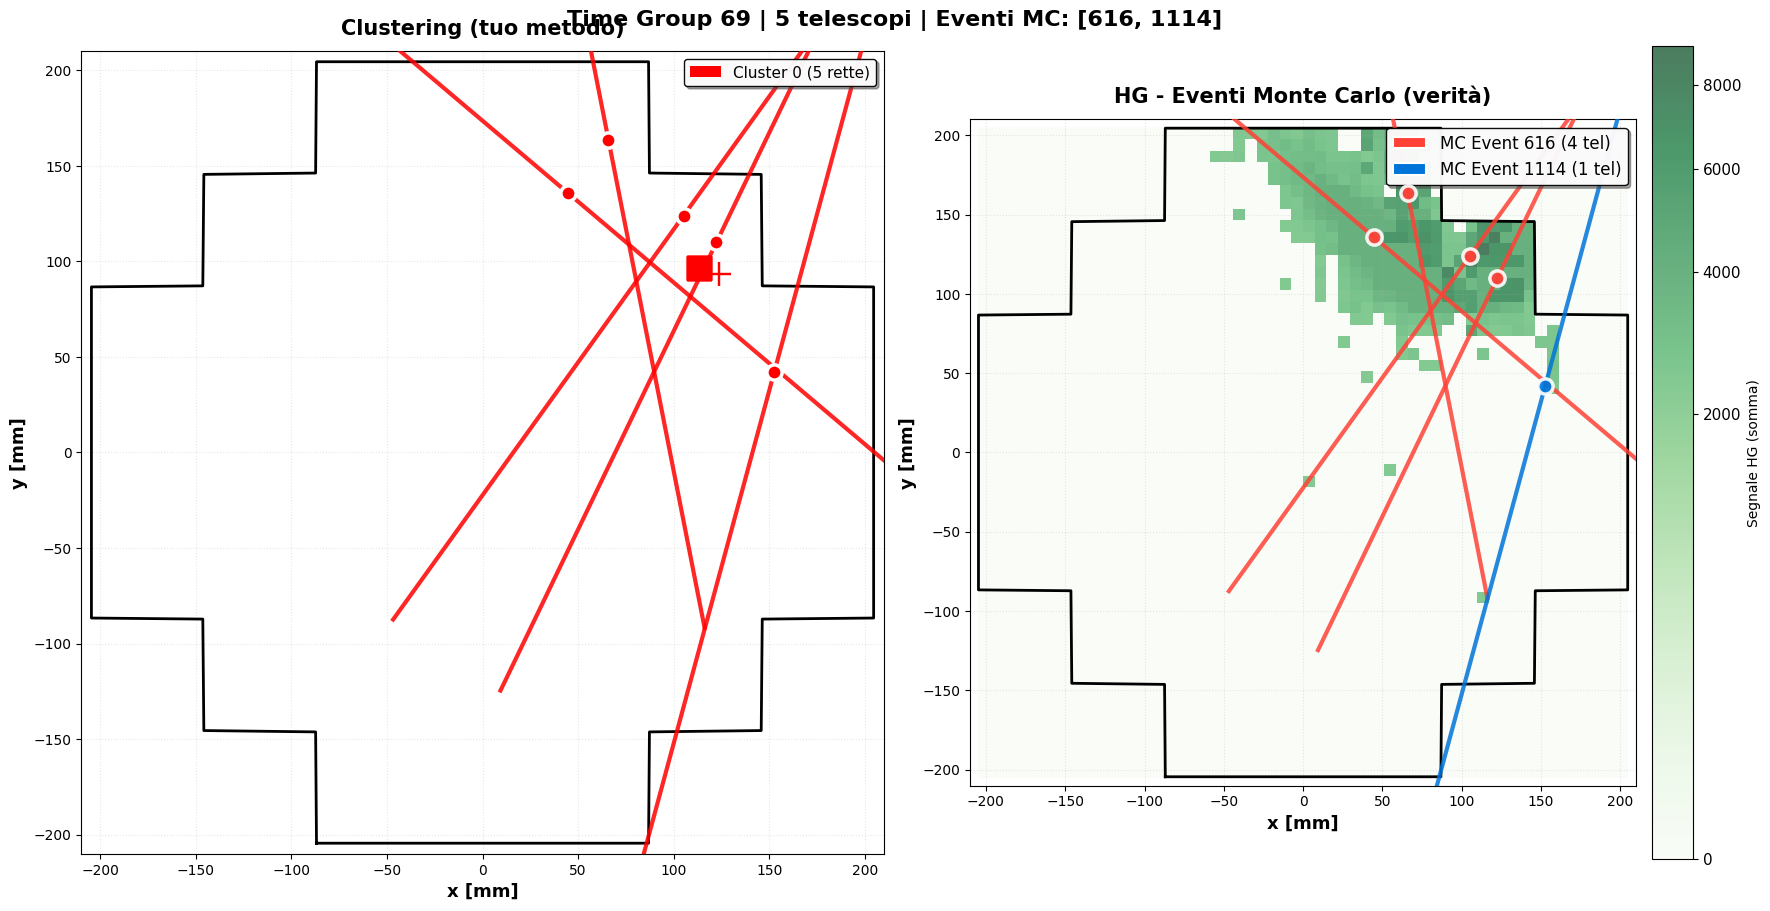

✓ Completato time_group 69
  Rette per evento MC: {616: 4, 1114: 1}
  Cluster trovati: [0]
  Rette per cluster: {0: 5, -1: 0}


TIME GROUP 751
Telescopi: 5 | Eventi MC: [40503 40514] | MCRUN: [220016]
mediana:  [  -5.5067158  -182.77526711]
mediana:  [  -5.5067158  -182.77526711]
mediana:  [  -5.5067158  -182.77526711]
mediana:  [  -5.5067158  -182.77526711]
mediana:  [  -5.5067158  -182.77526711]


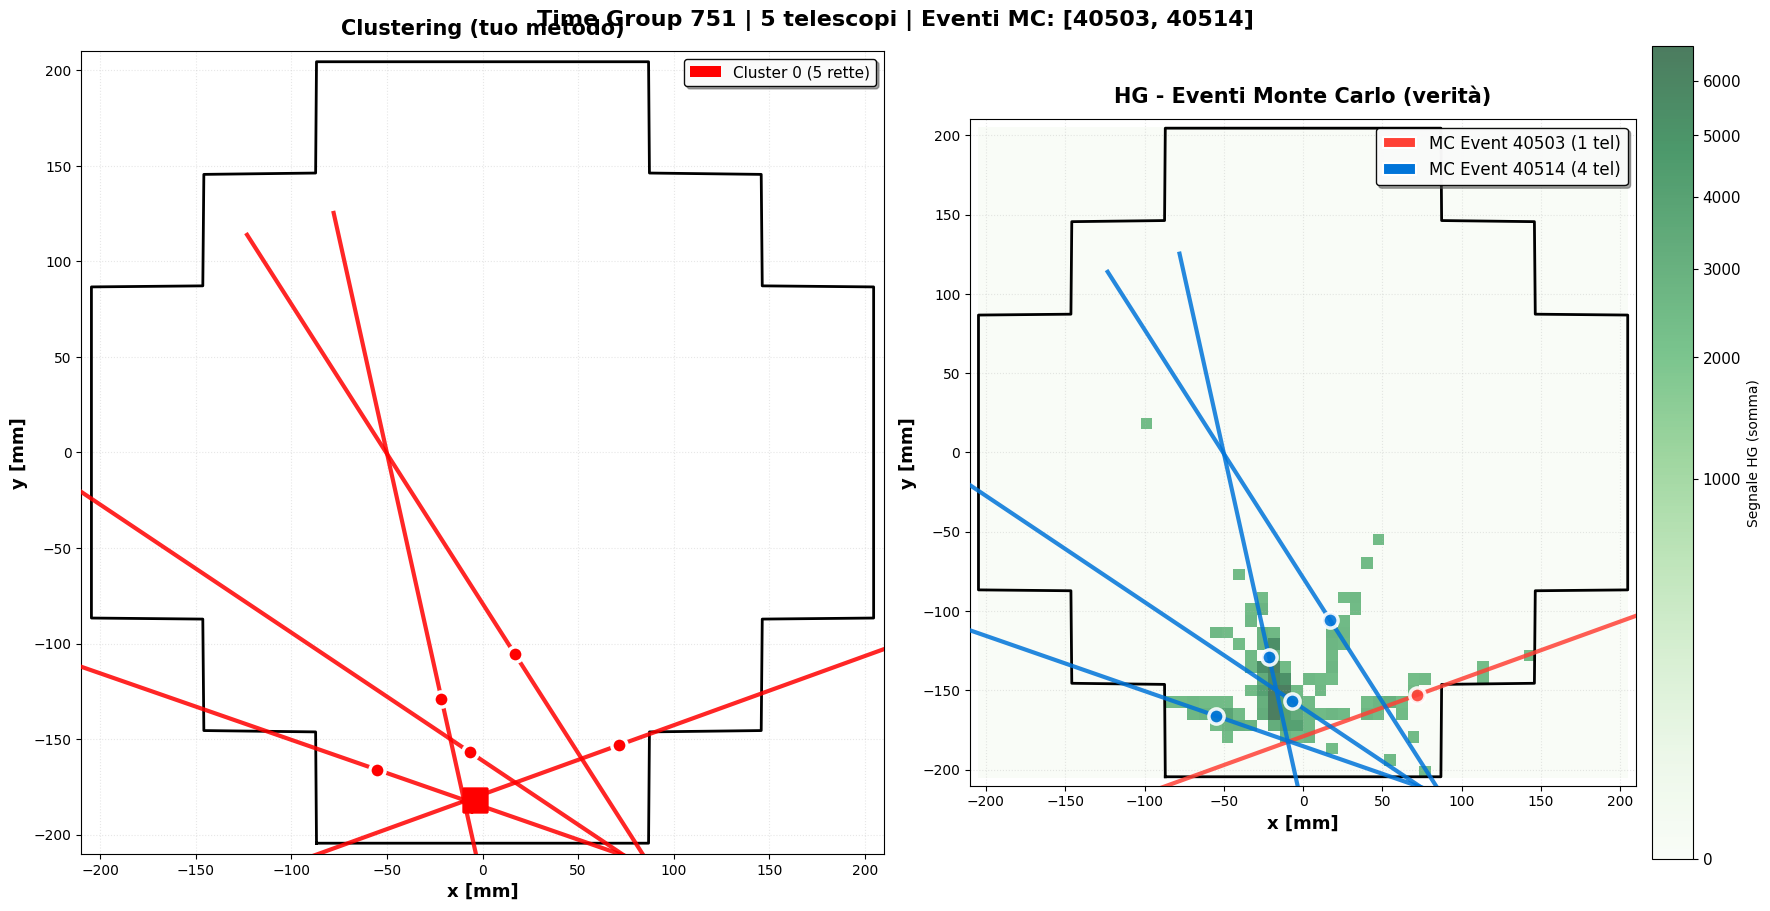

✓ Completato time_group 751
  Rette per evento MC: {40503: 1, 40514: 4}
  Cluster trovati: [0]
  Rette per cluster: {0: 5, -1: 0}


TIME GROUP 1681
Telescopi: 8 | Eventi MC: [3505 3516] | MCRUN: [220035]
mediana:  [-108.52325853 -187.55525004]
mediana:  [961.68537088 258.00603573]
mediana:  [-108.52325853 -187.55525004]
mediana:  [961.68537088 258.00603573]
mediana:  [-108.52325853 -187.55525004]
mediana:  [961.68537088 258.00603573]
mediana:  [-108.52325853 -187.55525004]
mediana:  [961.68537088 258.00603573]


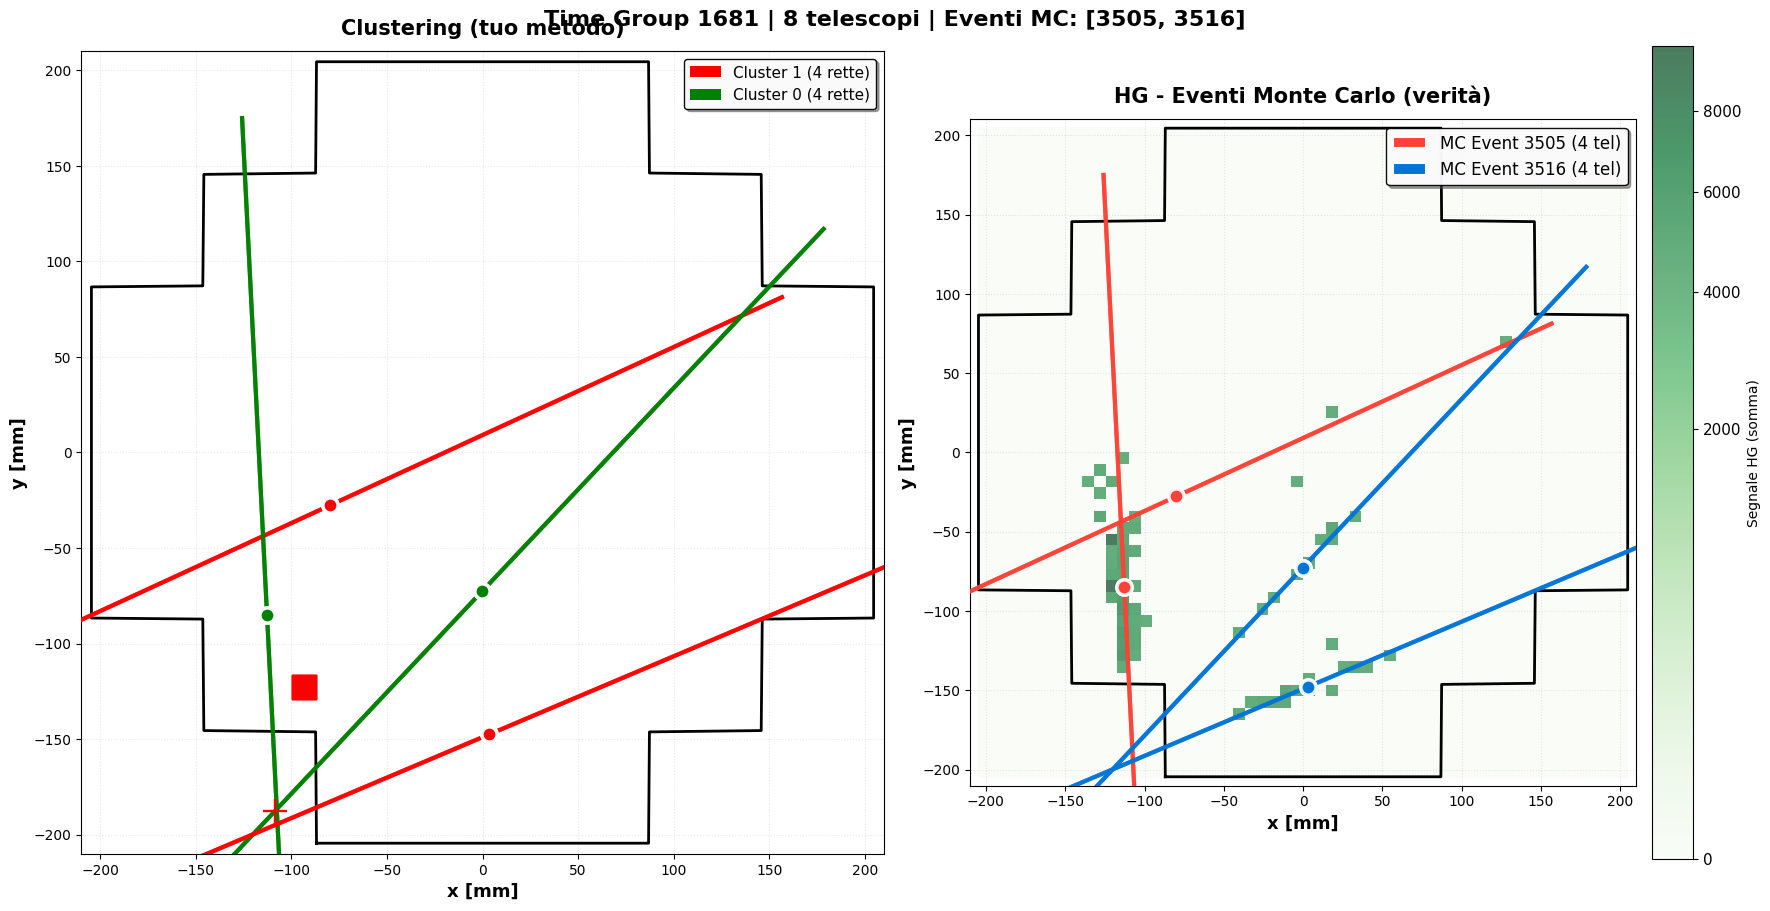

✓ Completato time_group 1681
  Rette per evento MC: {3505: 4, 3516: 4}
  Cluster trovati: [1, 0]
  Rette per cluster: {1: 4, 0: 4, -1: 0}


TIME GROUP 1959
Telescopi: 2 | Eventi MC: [26312 26603] | MCRUN: [220041]
mediana:  [ 144.66139386 -114.00828489]
mediana:  [ 144.66139386 -114.00828489]


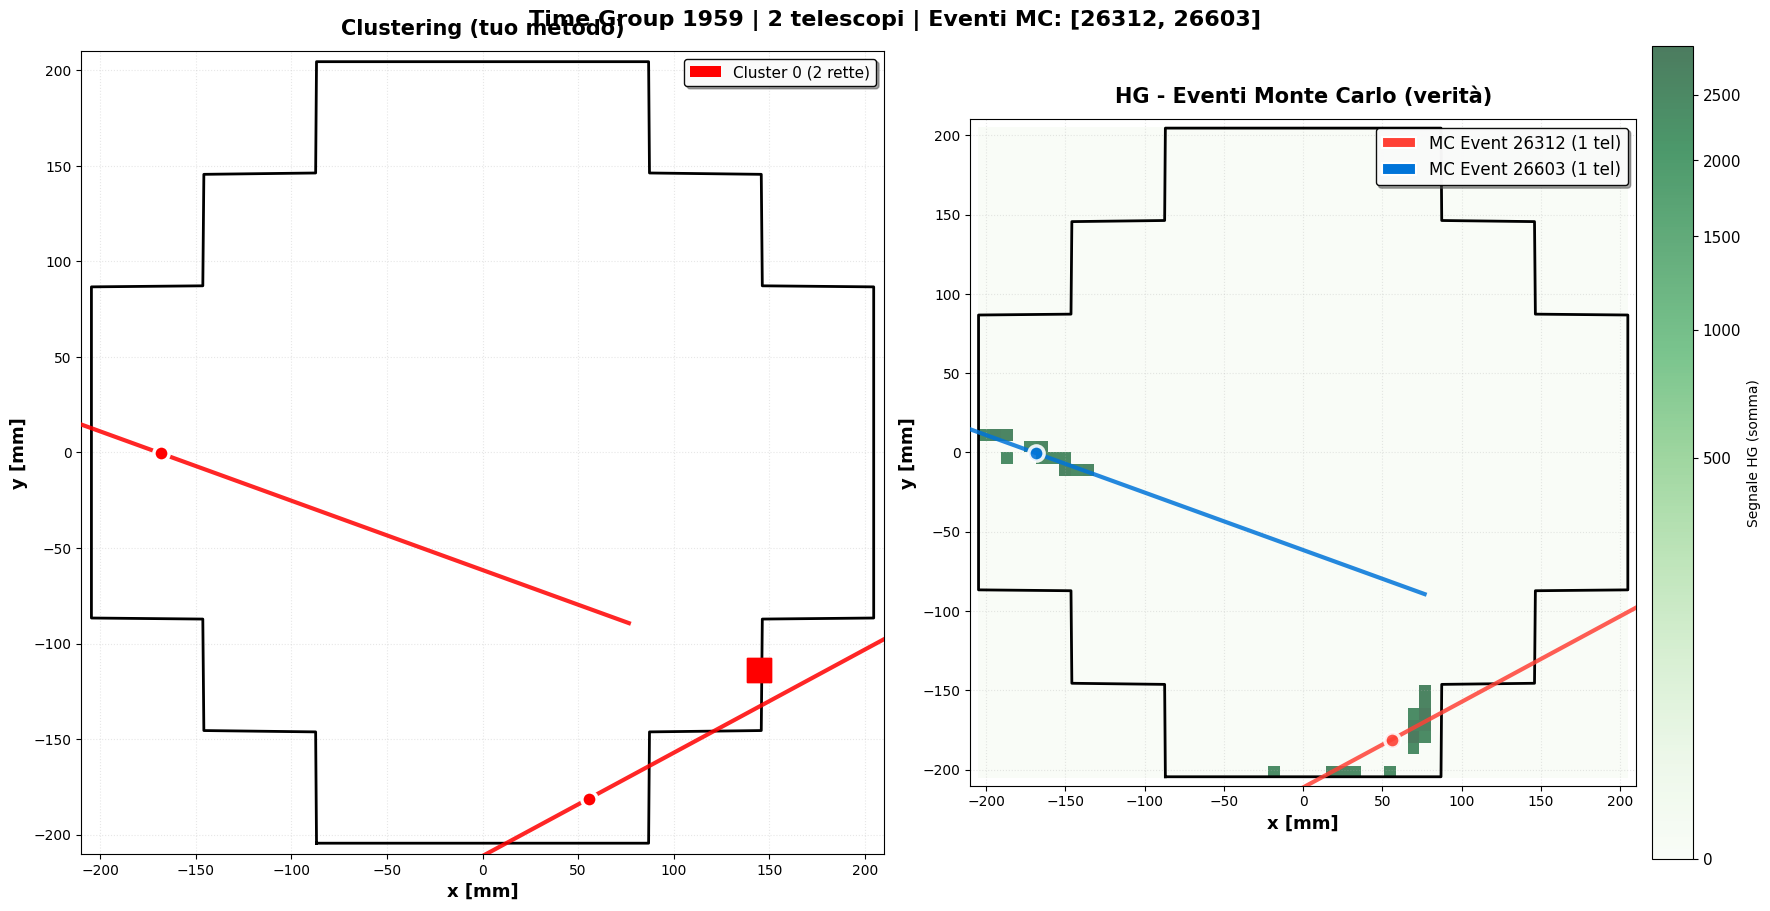

✓ Completato time_group 1959
  Rette per evento MC: {26312: 1, 26603: 1}
  Cluster trovati: [0]
  Rette per cluster: {0: 2, -1: 0}


TIME GROUP 2665
Telescopi: 7 | Eventi MC: [36317 36906] | MCRUN: [220256]
mediana:  [ -39.69611216 -140.19823147]
mediana:  [ -39.69611216 -140.19823147]
mediana:  [ -39.69611216 -140.19823147]
mediana:  [ -39.69611216 -140.19823147]
mediana:  [ -39.69611216 -140.19823147]
mediana:  [ -39.69611216 -140.19823147]
mediana:  [ -39.69611216 -140.19823147]


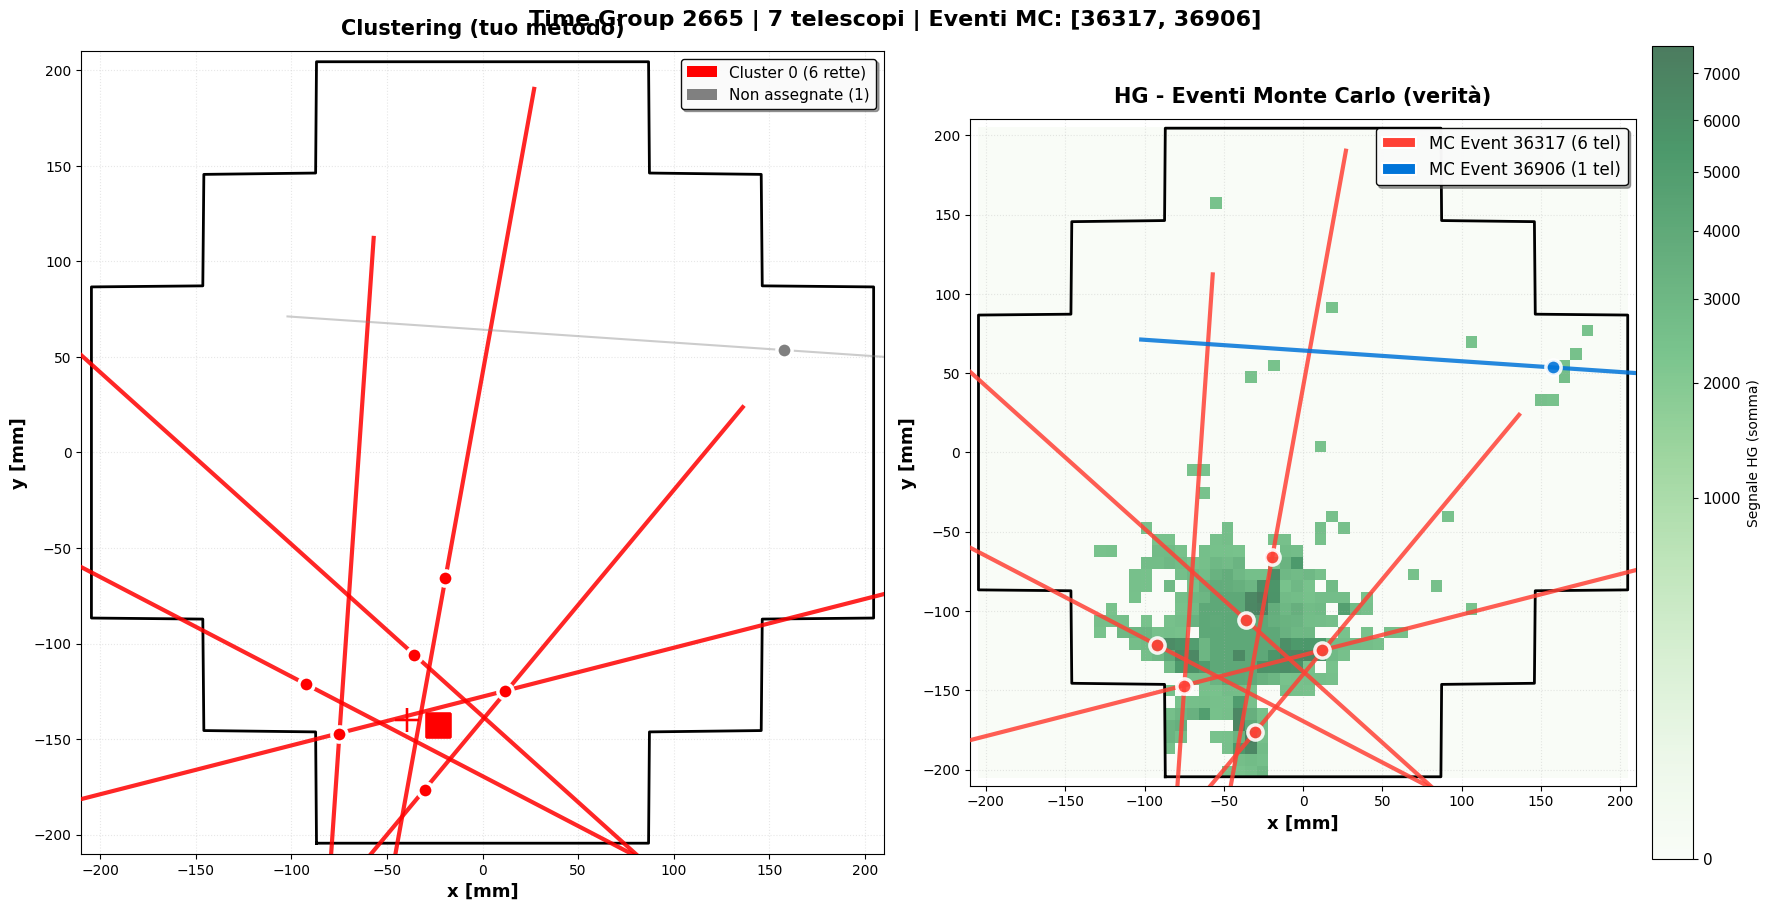

✓ Completato time_group 2665
  Rette per evento MC: {36317: 6, 36906: 1}
  Cluster trovati: [0]
  Rette per cluster: {0: 6, -1: 1}


TIME GROUP 3031
Telescopi: 3 | Eventi MC: [41407 41417] | MCRUN: [220264]
mediana:  [149.67523005  -2.98511704]
mediana:  [149.67523005  -2.98511704]
mediana:  [149.67523005  -2.98511704]


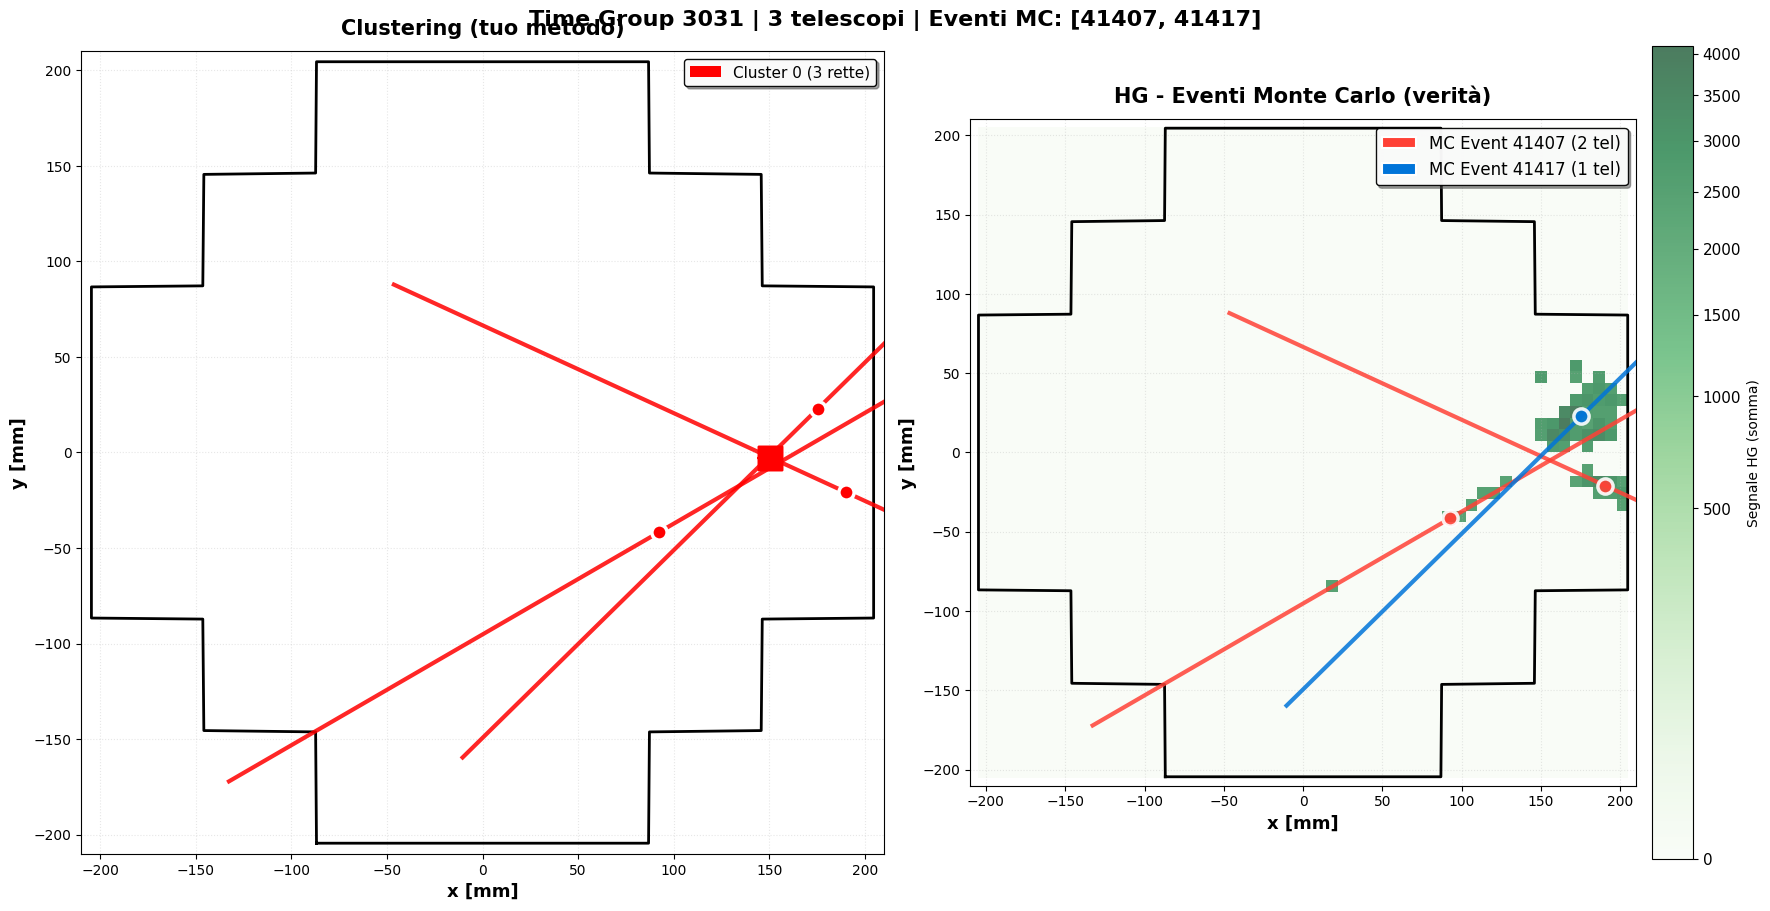

✓ Completato time_group 3031
  Rette per evento MC: {41407: 2, 41417: 1}
  Cluster trovati: [0]
  Rette per cluster: {0: 3, -1: 0}


TIME GROUP 3061
Telescopi: 5 | Eventi MC: [28701 28706] | MCRUN: [220265]
mediana:  [  27.0730007  -182.78235827]
mediana:  [  27.0730007  -182.78235827]
mediana:  [  27.0730007  -182.78235827]
mediana:  [  27.0730007  -182.78235827]
mediana:  [  27.0730007  -182.78235827]


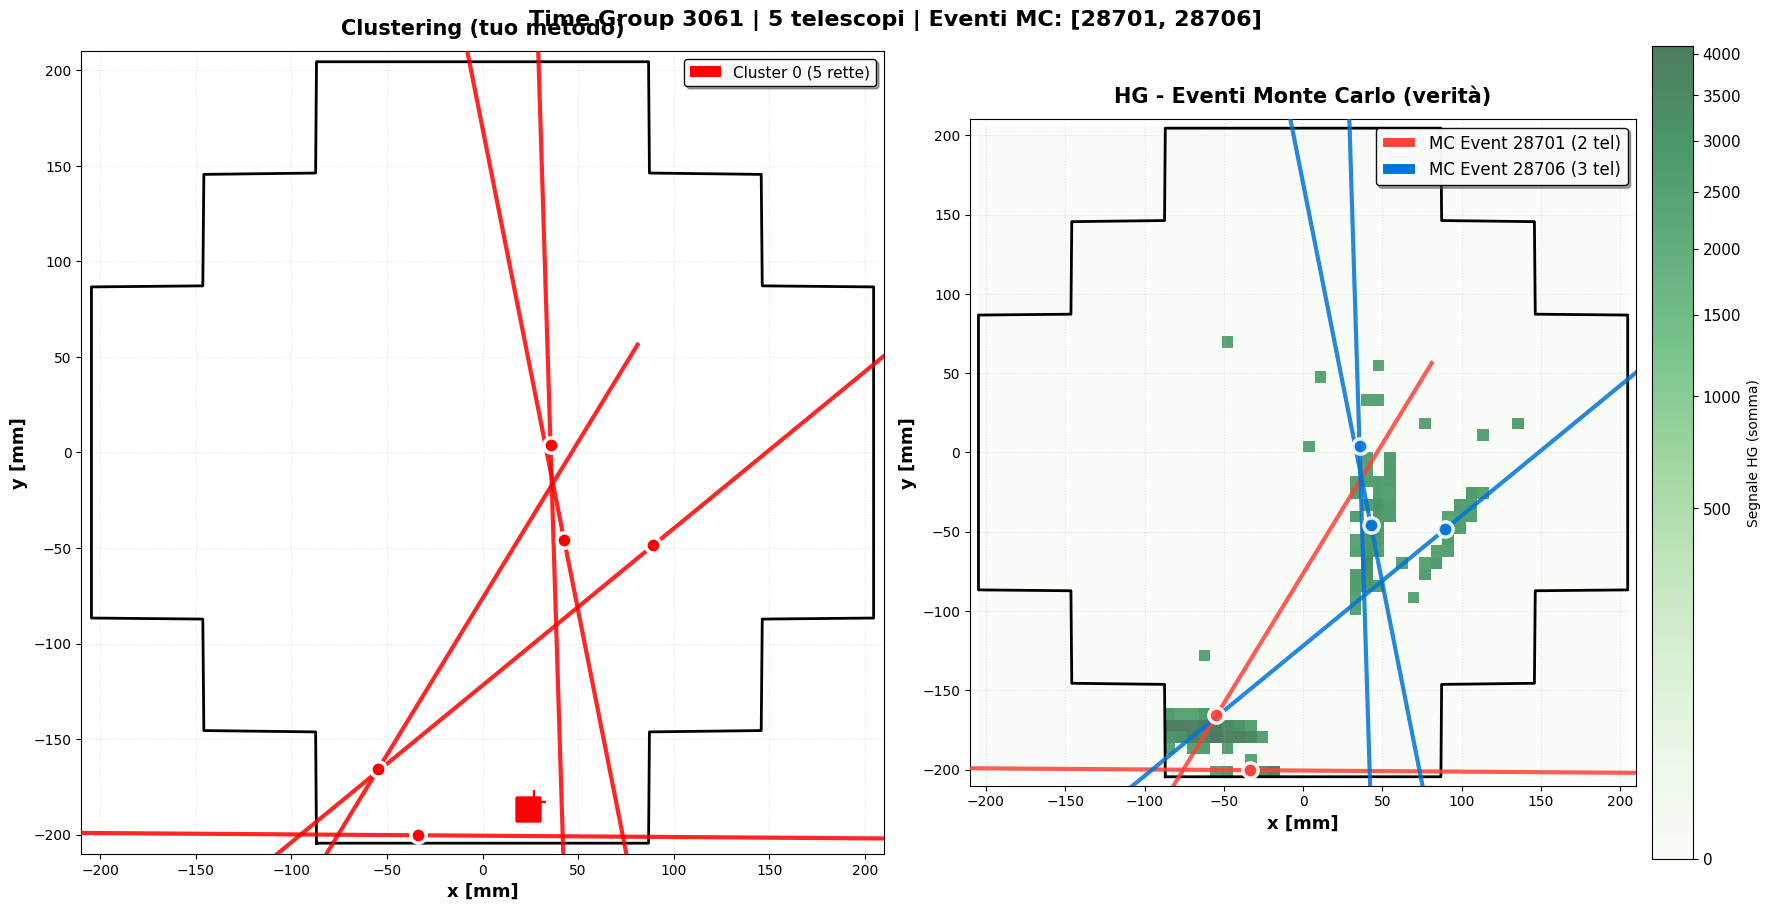

✓ Completato time_group 3061
  Rette per evento MC: {28701: 2, 28706: 3}
  Cluster trovati: [0]
  Rette per cluster: {0: 5, -1: 0}


TIME GROUP 3165
Telescopi: 4 | Eventi MC: [43007 42517] | MCRUN: [220267]
mediana:  [-63.29737574 -32.84126267]
mediana:  [-63.29737574 -32.84126267]
mediana:  [-63.29737574 -32.84126267]
mediana:  [-63.29737574 -32.84126267]


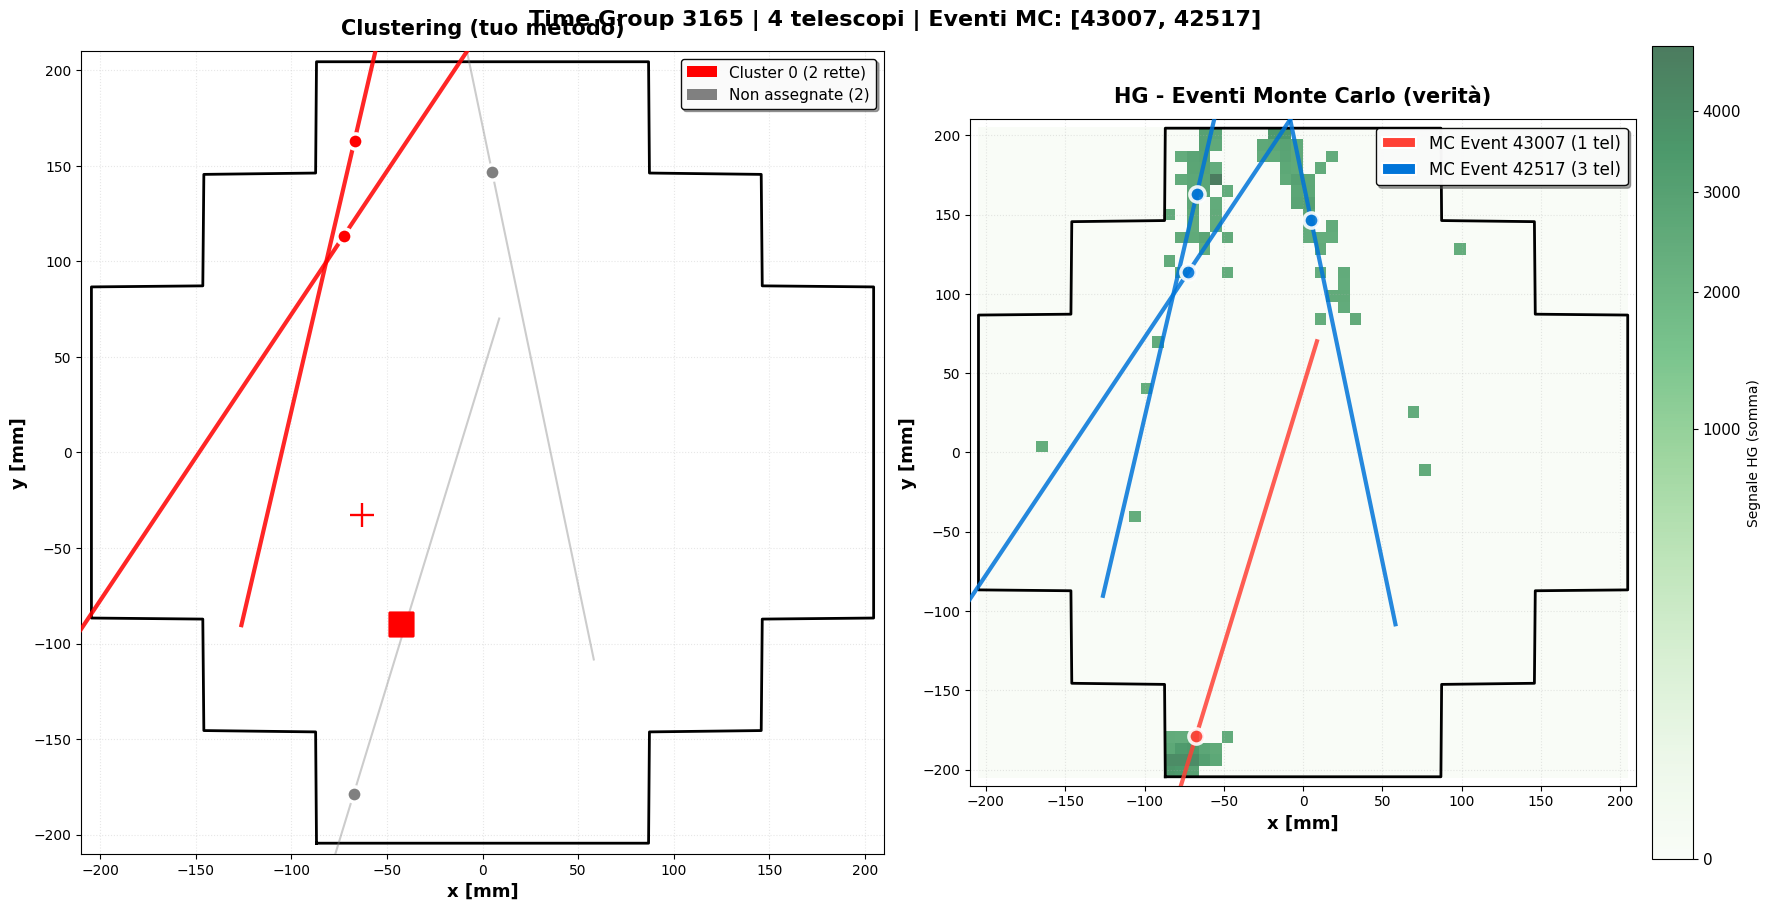

✓ Completato time_group 3165
  Rette per evento MC: {43007: 1, 42517: 3}
  Cluster trovati: [0]
  Rette per cluster: {0: 2, -1: 2}


TIME GROUP 3246
Telescopi: 18 | Eventi MC: [41912 41913] | MCRUN: [220269]
mediana:  [ -21.9836664  -270.35560735]
mediana:  [-195.67043742  562.1085438 ]
mediana:  [ 195.49356337 -560.62126375]
mediana:  [ -21.9836664  -270.35560735]
mediana:  [-195.67043742  562.1085438 ]
mediana:  [ 195.49356337 -560.62126375]
mediana:  [ -21.9836664  -270.35560735]
mediana:  [-195.67043742  562.1085438 ]
mediana:  [ 195.49356337 -560.62126375]
mediana:  [ -21.9836664  -270.35560735]
mediana:  [-195.67043742  562.1085438 ]
mediana:  [ 195.49356337 -560.62126375]
mediana:  [ -21.9836664  -270.35560735]
mediana:  [-195.67043742  562.1085438 ]
mediana:  [ 195.49356337 -560.62126375]
mediana:  [ -21.9836664  -270.35560735]
mediana:  [-195.67043742  562.1085438 ]
mediana:  [ 195.49356337 -560.62126375]


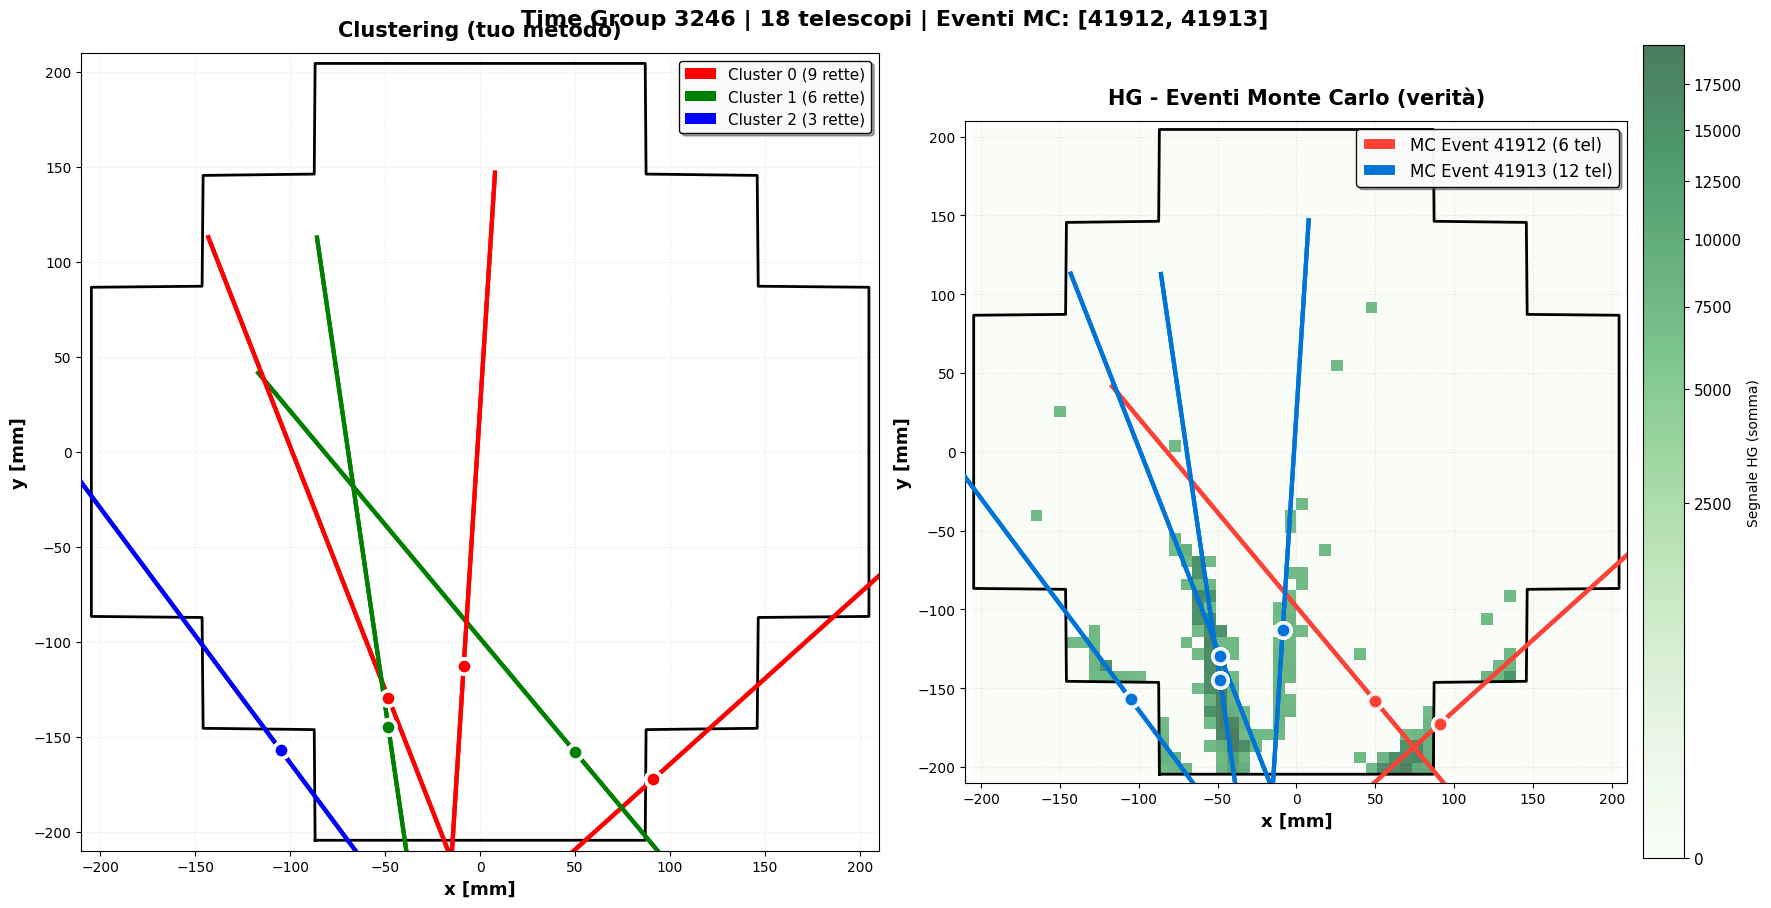

✓ Completato time_group 3246
  Rette per evento MC: {41912: 6, 41913: 12}
  Cluster trovati: [0, 1, 2]
  Rette per cluster: {0: 9, 1: 6, 2: 3, -1: 0}


TIME GROUP 3572
Telescopi: 2 | Eventi MC: [48611 48613] | MCRUN: [220276]
mediana:  [240.76246287 -82.76908989]
mediana:  [240.76246287 -82.76908989]


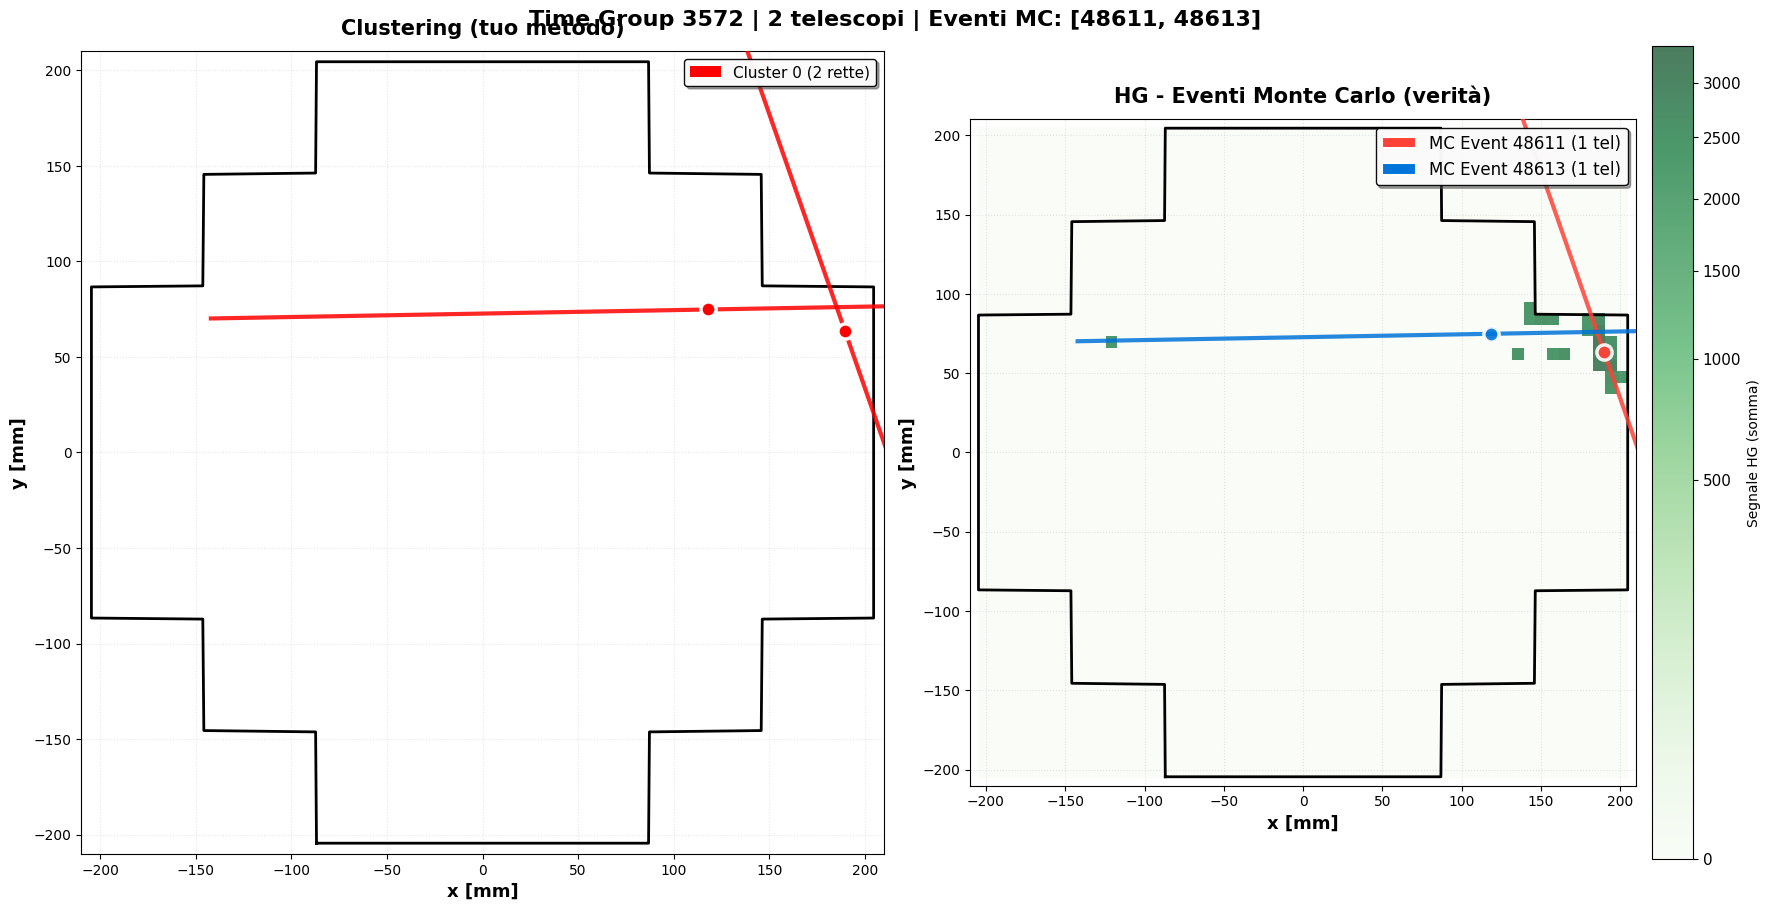

✓ Completato time_group 3572
  Rette per evento MC: {48611: 1, 48613: 1}
  Cluster trovati: [0]
  Rette per cluster: {0: 2, -1: 0}


TIME GROUP 3855
Telescopi: 12 | Eventi MC: [40514 40603] | MCRUN: [220283]
mediana:  [-54.45878699 255.9210278 ]
mediana:  [ 909.48924441 -315.05413751]
mediana:  [-54.45878699 255.9210278 ]
mediana:  [ 909.48924441 -315.05413751]
mediana:  [-54.45878699 255.9210278 ]
mediana:  [ 909.48924441 -315.05413751]
mediana:  [-54.45878699 255.9210278 ]
mediana:  [ 909.48924441 -315.05413751]
mediana:  [-54.45878699 255.9210278 ]
mediana:  [ 909.48924441 -315.05413751]
mediana:  [-54.45878699 255.9210278 ]
mediana:  [ 909.48924441 -315.05413751]


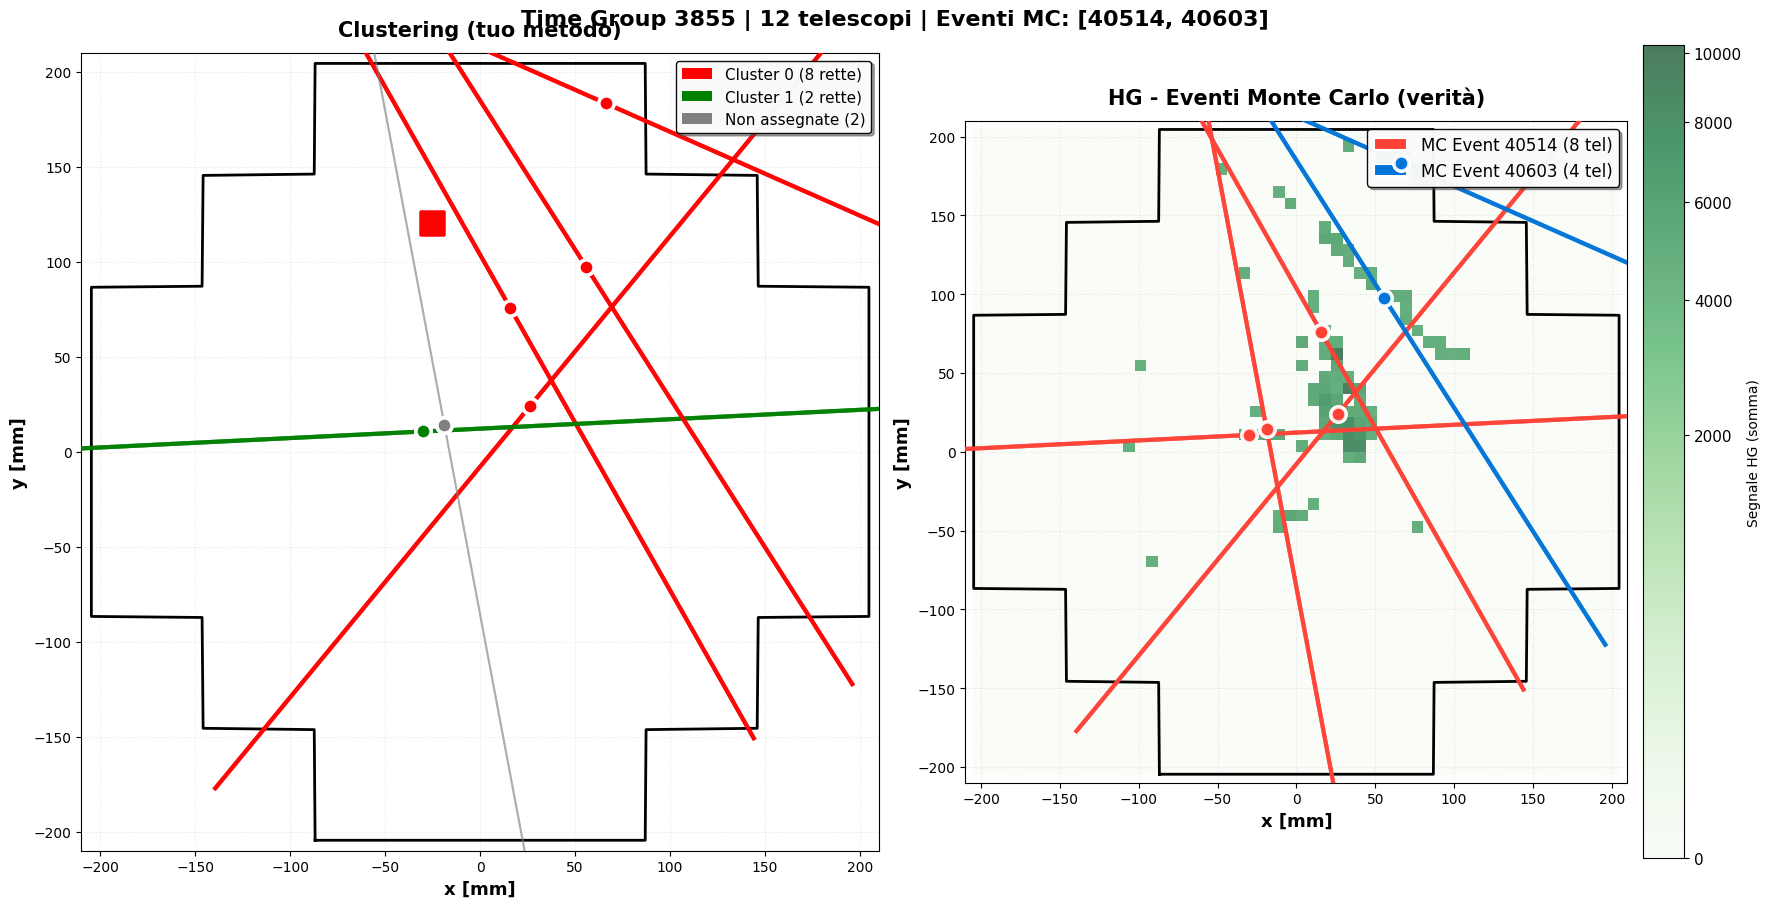

✓ Completato time_group 3855
  Rette per evento MC: {40514: 8, 40603: 4}
  Cluster trovati: [0, 1]
  Rette per cluster: {0: 8, 1: 2, -1: 2}


TIME GROUP 4526
Telescopi: 8 | Eventi MC: [12808 12810] | MCRUN: [220297]
mediana:  [-279.75953986   14.93574855]
mediana:  [-279.75953986   14.93574855]
mediana:  [-279.75953986   14.93574855]
mediana:  [-279.75953986   14.93574855]
mediana:  [-279.75953986   14.93574855]
mediana:  [-279.75953986   14.93574855]
mediana:  [-279.75953986   14.93574855]
mediana:  [-279.75953986   14.93574855]


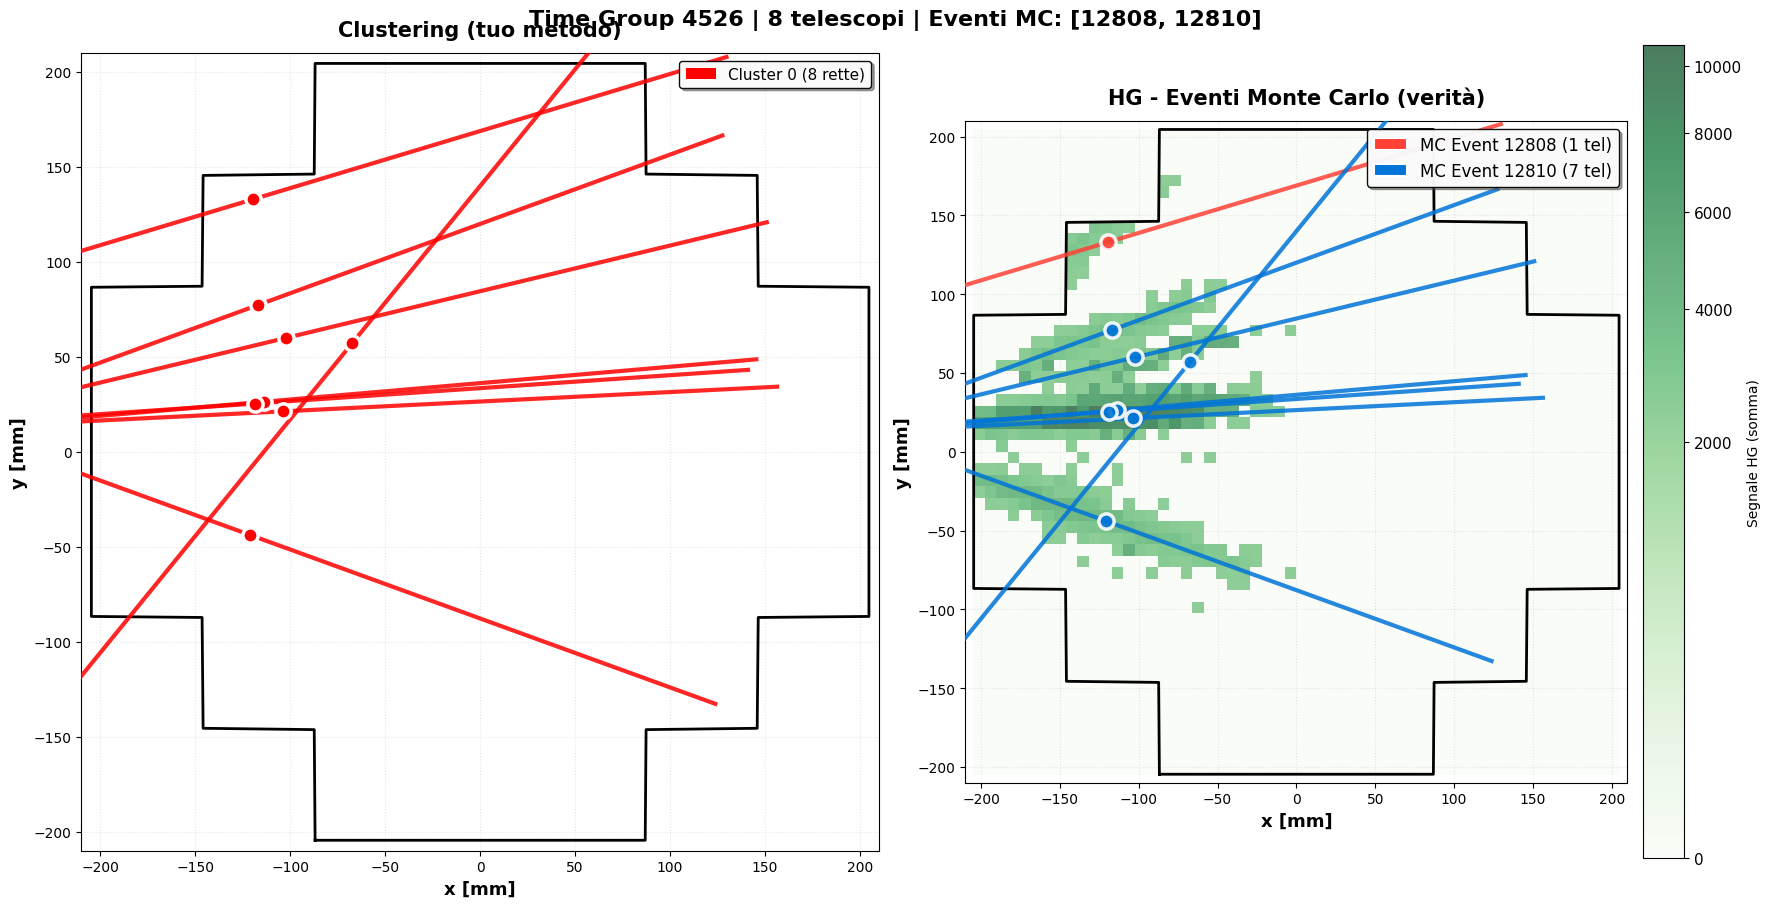

✓ Completato time_group 4526
  Rette per evento MC: {12808: 1, 12810: 7}
  Cluster trovati: [0]
  Rette per cluster: {0: 8, -1: 0}



In [166]:

xfp, yfp = at.utils.camera.get_xy_footprint()
y_pix, x_pix = at.utils.camera.get_pixels_position_matrix().T
x_pix = at.reshape(x_pix)
y_pix = at.reshape(y_pix)

# Lunghezza rette
xmin, xmax = np.min(xfp), np.max(xfp)
ymin, ymax = np.min(yfp), np.max(yfp)
diag = np.sqrt((xmax - xmin)**2 + (ymax - ymin)**2)
L = 0.45 * diag

for time_group in df_merged['time_group'].drop_duplicates().values[:]:
    
    # ===================================================================
    # PREPARAZIONE DATI
    # ===================================================================
    
    # Estrai tutti i telescopi di questo gruppo temporale
    df_window = df_merged[df_merged['time_group'] == time_group].copy()
    
    # Informazioni sul gruppo
    unique_events = df_window['EVENT'].unique()
    unique_mcruns = df_window['MCRUN'].unique()
    
    print(f"\n{'='*70}")
    print(f"TIME GROUP {time_group}")
    print(f"Telescopi: {len(df_window)} | Eventi MC: {unique_events} | MCRUN: {unique_mcruns}")
    print(f"{'='*70}")
    
    # ===================================================================
    # PLOT SIDE-BY-SIDE
    # ===================================================================
    
    fig, ax = plt.subplots(1, 2, figsize=(18, 9))
    
    # Colori per cluster assegnati (il tuo metodo)
    cluster_trovati = df_window[df_window['is_assigned']]['assigned_cluster'].unique()
    colori_cluster = {cluster_trovati[i]: ['red', 'green', 'blue', 'orange', 'cyan'][i % 5] 
                     for i in range(len(cluster_trovati))}
    colori_cluster[-1] = 'gray'  # outliers
    
    # Colori per eventi MC
    colors_mc = ['#FF4136', '#0074D9', '#2ECC40', '#FF851B']
    event_color_map = {unique_events[i]: colors_mc[i % len(colors_mc)] for i in range(len(unique_events))}
    
    # Contatori
    rette_per_cluster = {c: 0 for c in cluster_trovati}
    rette_per_cluster[-1] = 0  # outliers
    rette_per_evento = {ev: 0 for ev in unique_events}
    
    # Inizializza array per heatmap
    weights_hg = np.zeros((37, 64))
    mask_tot = np.zeros((37, 64), dtype=bool)
    
    # ─── SINISTRA: cLUSTERING ───────────────────────────────────
    for idx, row in df_window.iterrows():
        
        hgev = np.array(row['HG'])
        ttpev = np.array(row['TTP'])
        pxmask = (hgev > 2400) & (ttpev < 255)
        centro0=np.array(row['P_median'])
        centro1=np.array(row['P_weight'])

        print("mediana: ", centro0)
        if not np.any(pxmask):
            continue
        
        # Centroide
        meanx_hg = np.average(x_pix[pxmask].flatten(), weights=hgev[pxmask].flatten())
        meany_hg = np.average(y_pix[pxmask].flatten(), weights=hgev[pxmask].flatten())
        
        # Covarianza per direzione
        cov_hg = np.cov([x_pix[pxmask].flatten(), y_pix[pxmask].flatten()], 
                        aweights=hgev[pxmask].flatten())
        l1_hg = (cov_hg[0,0] + cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0] - cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
        
        # Cluster assegnato
        if row['is_assigned']:
            cluster_id = row['assigned_cluster']
            col = colori_cluster.get(cluster_id, 'purple')
            alpha = 0.85
            lw = 3.0
            rette_per_cluster[cluster_id] += 1
        else:
            col = 'gray'
            alpha = 0.4
            lw = 1.5
            rette_per_cluster[-1] += 1
        
        # Disegna retta
        x1 = meanx_hg - L * np.cos(theta_hg)
        y1 = meany_hg - L * np.sin(theta_hg)
        x2 = meanx_hg + L * np.cos(theta_hg)
        y2 = meany_hg + L * np.sin(theta_hg)
        
        ax[0].plot([x1, x2], [y1, y2], color=col, linewidth=lw, alpha=alpha, zorder=5)
        ax[0].scatter(meanx_hg, meany_hg, s=120, color=col, edgecolor='white', linewidth=2.5, zorder=6)

        if centro0.ndim == 1:
        # È un singolo punto
            ax[0].scatter(centro0[0], centro0[1], marker='+', s=320, c='red', zorder=6,label="mediana")
            ax[0].scatter(centro1[0], centro1[1], marker='s', s=320, c='red', zorder=6,label="media pesata")
        elif centro0.ndim == 2:
        # Sono multipli punti
            ax[0].scatter(centro0[:, 0], centro0[:, 1], marker='+', s=320, c='red', zorder=6,label="mediana")
            ax[0].scatter(centro1[:,0], centro1[:,1], marker='s', s=320, c='red', zorder=6,label="media pesata")
            
    # Disegna centri cluster (se presenti in df_window)
    for cluster_id in cluster_trovati:
        cluster_rows = df_window[df_window['assigned_cluster'] == cluster_id]
        if len(cluster_rows) > 0 and 'center_x' in cluster_rows.columns:
            center_x = cluster_rows['center_x'].iloc[0]
            center_y = cluster_rows['center_y'].iloc[0]
            ax[0].scatter(center_x, center_y, marker='+', s=500, 
                         c=colori_cluster.get(cluster_id, 'black'), linewidth=4, zorder=7)
    
    ax[0].plot(xfp, yfp, 'k-', linewidth=2, zorder=2)
    ax[0].set_title(f'Clustering (tuo metodo)', fontweight='bold', fontsize=15, pad=12)
    ax[0].set_xlim(-210, 210)
    ax[0].set_ylim(-210, 210)
    ax[0].set_aspect('equal')
    ax[0].set_xlabel('x [mm]', fontsize=13, fontweight='bold')
    ax[0].set_ylabel('y [mm]', fontsize=13, fontweight='bold')
    ax[0].grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
    
    # Legenda clustering
    legend_clustering = []
    for c in cluster_trovati:
        if rette_per_cluster[c] > 0:
            legend_clustering.append(Patch(facecolor=colori_cluster[c], 
                                          label=f'Cluster {c} ({rette_per_cluster[c]} rette)'))
    if rette_per_cluster[-1] > 0:
        legend_clustering.append(Patch(facecolor='gray', 
                                      label=f'Non assegnate ({rette_per_cluster[-1]})'))
    ax[0].legend(handles=legend_clustering, loc='upper right', fontsize=11, 
                framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
    
    # ─── DESTRA: HG CON EVENTI MC ─────────────────────────────────────
    for idx, row in df_window.iterrows():
        
        hgev = np.array(row['HG'])
        ttpev = np.array(row['TTP'])
        pxmask = (hgev > 2400) & (ttpev < 255)
        
        if not np.any(pxmask):
            continue
        
        # Somma per heatmap
        weights_hg[pxmask] += hgev[pxmask]
        mask_tot |= pxmask
        
        # Centroide
        meanx_hg = np.average(x_pix[pxmask].flatten(), weights=hgev[pxmask].flatten())
        meany_hg = np.average(y_pix[pxmask].flatten(), weights=hgev[pxmask].flatten())
        
        # Covarianza
        cov_hg = np.cov([x_pix[pxmask].flatten(), y_pix[pxmask].flatten()], 
                        aweights=hgev[pxmask].flatten())
        l1_hg = (cov_hg[0,0] + cov_hg[1,1])/2 + np.sqrt(((cov_hg[0,0] - cov_hg[1,1])/2)**2 + cov_hg[0,1]**2)
        theta_hg = np.arctan2(l1_hg - cov_hg[0,0], cov_hg[0,1])
        
        color_ev = event_color_map[row['EVENT']]
        rette_per_evento[row['EVENT']] += 1
        
        ax[1].scatter(meanx_hg, meany_hg, s=120, color=color_ev, 
                     edgecolor='white', linewidth=2.5, zorder=6, alpha=0.9)
        
        x1 = meanx_hg - L * np.cos(theta_hg)
        y1 = meany_hg - L * np.sin(theta_hg)
        x2 = meanx_hg + L * np.cos(theta_hg)
        y2 = meany_hg + L * np.sin(theta_hg)
        ax[1].plot([x1, x2], [y1, y2], color=color_ev, linewidth=3, alpha=0.85, zorder=5)
    
    # Heatmap
    h1 = ax[1].hist2d(x_pix[mask_tot].flatten(), y_pix[mask_tot].flatten(),
                     weights=weights_hg[mask_tot].flatten(), 
                     range=((-205, 205), (-205, 205)),
                     bins=7*8, cmap='Greens', alpha=0.7, norm=PowerNorm(0.4))
    
    ax[1].plot(xfp, yfp, 'k-', linewidth=2, zorder=2)
    ax[1].set_xlim(-210, 210)
    ax[1].set_ylim(-210, 210)
    ax[1].set_aspect('equal')
    ax[1].set_xlabel('x [mm]', fontsize=13, fontweight='bold')
    ax[1].set_ylabel('y [mm]', fontsize=13, fontweight='bold')
    ax[1].grid(True, alpha=0.3, linestyle=':', linewidth=0.8)
    ax[1].set_title(f'HG - Eventi Monte Carlo (verità)', fontweight='bold', fontsize=15, pad=12)
    
    # Colorbar
    cbar1 = fig.colorbar(h1[3], ax=ax[1], label='Segnale HG (somma)', pad=0.02)
    cbar1.ax.tick_params(labelsize=11)
    
    # Legenda eventi MC
    legend_mc = [
        Patch(facecolor=event_color_map[ev], edgecolor='white', linewidth=1.5,
              label=f'MC Event {ev} ({rette_per_evento[ev]} tel)')
        for ev in unique_events
    ]
    ax[1].legend(handles=legend_mc, loc='upper right', fontsize=12, 
                framealpha=0.95, edgecolor='black', fancybox=True, shadow=True)
    
    plt.suptitle(f'Time Group {time_group} | {len(df_window)} telescopi | Eventi MC: {list(unique_events)}',
                fontsize=16, fontweight='bold', y=0.98)
    plt.tight_layout()
    plt.show()
    
    print(f"✓ Completato time_group {time_group}")
    print(f"  Rette per evento MC: {rette_per_evento}")
    print(f"  Cluster trovati: {list(cluster_trovati)}")
    print(f"  Rette per cluster: {rette_per_cluster}\n")